# Bayesian Optimisation: ERK single-pulse dose-response (v3 -- Hill only, tighter baseline filter)

Per FOV protocol unchanged from v1/v2: 5 min baseline -> 1 stim frame ->
25 min observation. 31 frames at 1 frame/min = **~31 minutes of microscope
time per phase**. This is the binding bottleneck.

## What changed from v2, and why

v2 ran with three candidate dose-response families (hill, exponential,
power_law). The algorithm picked `exponential`; post-hoc residual fitting
showed `exponential` and `hill` are statistically tied on this readout
(RMSE difference 0.001 on a y-range of 12.5). The candidate-overlay plot
showed their posterior curves are visually identical. **The data does not
discriminate hill from exp at this dose density** -- the response is
saturating with K ~ 1000 ms, but the underlying mechanism (cooperative
vs first-order kinetics) is not resolved.

v3 makes two changes:

### Change 1: Single candidate -- Hill only

Drop the hypothesis-learning machinery and commit to Hill as the mean
function. Justification:

- Hill is the canonical biological model for cooperative receptor
  signalling (incl. ERK/MAPK cascades).
- v2 showed hypothesis learning cannot discriminate hill vs exp on this
  data; spending eps-greedy budget on the discrimination question wastes
  microscope time.
- The 1.51x EC50 precision advantage v2 demonstrated over uniform-grid
  sampling comes from **active-learning acquisition** (MaxVar over the GP
  posterior variance), not from model selection. That advantage transfers
  directly to v3.

The result of v3 is a **Hill parameter posterior**: median + 95% CI on
each of `V_max` (asymptote), `K` (EC50, in ms), `n` (Hill coefficient).
That is the experimental output.

### Change 2: Tighter per-cell baseline filter (`max_baseline_cnr=0.8`)

v1 and v2 used `max_baseline_cnr=1.0` -- cells whose mean baseline CNR
over the first 5 frames was below 1.0 were retained for the AUC computation.
Tighter is better here because cells with high resting ERK activity have
less response headroom; including them dilutes the dose-response signal.

v3 lowers this to **0.8**. The filter applies only to which cells feed
the BO objective; it does not touch the FOV finder's well-selection logic
(`min_cells=35`, `max_cells=250` are unchanged).

## Pitch

> "Microscope time is the binding constraint. v3 commits to Hill (the
> canonical biological dose-response family) and runs BO with active-learning
> acquisition to extract the parameter posterior at minimal microscope cost.
> At equal FOV budget, the K (EC50) posterior is ~1.5x tighter than a
> uniform-grid screen would produce (from v2 evidence). Output:
> `K, n, V_max` with quantified uncertainty in ~5 h of microscope time."

## BO model (carried over from v2)

`gpax.ExactGP` with Hill mean function, MaxVar acquisition over the
sum of standardised posterior variances (AUC is primary; frac is secondary).
Two covariates: `optortk_expression` (log-scaled), `baseline_cnr`.
Wider lengthscale prior `Uniform(0.1, 5.0)` for ARD interpretability.
`penalty_factor=1.0` (less repulsion than v1's 2.0; lets MaxVar
concentrate where uncertainty is highest).


In [1]:
import os
import time
import types
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress JAX/XLA debug messages
os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import jax
import jax.numpy as jnp

jax.config.update("jax_log_compiles", False)
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)

# ---------------------------------------------------------------------------
# gpax/numpyro compatibility shim
# ---------------------------------------------------------------------------
# numpyro >= 0.20 removed haiku support from numpyro.contrib.module, but
# gpax 0.1.9 eagerly imports viDKL via gpax/models/__init__.py, which tries
# `from numpyro.contrib.module import random_haiku_module, haiku_module`.
# We don't use viDKL (only ExactGP), so we install stubs that raise only if
# viDKL is actually called. This MUST run before any `import gpax` (including
# the lazy ones inside the BO agent classes).
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError(
        "haiku support was removed from numpyro >= 0.20. "
        "viDKL is not available. Use ExactGP, viGP, or viSparseGP."
    )


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable
# ---------------------------------------------------------------------------

import numpyro
import numpyro.distributions as dist

# Enable float64 BEFORE any gpax.ExactGP.fit() call. gpax 0.1.9 has a
# Cholesky-instability bug in float32 that produces ~99% NaN in predict()
# outputs for typical covariate-marginalised dose grids. Float64 fixes it.
import gpax.utils as _gpax_utils

_gpax_utils.enable_x64()


from faro.core.data_structures import (
    PowerChannel,
    SegmentationMethod,
)
from faro.core.controller import Controller
from faro.core.pipeline import ImageProcessingPipeline
from faro.agents.bo_optimization import (
    BO_Parameter,
    BO_Objective,
    BO_Covariate,
    StandardScalerBounds,
)
from faro.agents.bo_dose_response import DoseResponseBO
import faro.core.utils as utils

## Microscope & pipeline setup

Same hardware/pipeline layout as the v8 oscillation notebook. Channels:

- **Imaging**: miRFP (nuclear marker) + mScarlet3 (ERK-KTR reporter)
- **Stimulation**: CyanStim (whole FOV; exposure overridden per condition by the BO agent)
- **Optocheck**: mCitrine (mCitrine intensity = optoRTK expression covariate, last frame only)

In [2]:
from faro.microscope.pertzlab.jungfrau import Jungfrau

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [ ]:
import napari
from napari_micromanager import MainWindow

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc
viewer.window.add_dock_widget(mm_wdg)

In [3]:
WELLS = []
START_COL = 2
END_COL = 12
for i, row in enumerate("ABCDEFGH"):
    cols = (
        range(START_COL, END_COL + 1)
        if i % 2 == 0
        else range(END_COL, START_COL - 1, -1)
    )
    WELLS.extend(f"{row}{c}" for c in cols)

WELLS = WELLS

In [10]:
N_PHASES * N_WELLS_PER_PHASE

48

In [11]:
len(WELLS)

48

In [4]:
# --- Experiment timing ---
TIME_BETWEEN_TIMESTEPS = 60  # seconds (1 frame/min)

# Phase layout (frames; 1 frame == 1 minute):
#   10 min baseline -> 1 stim frame -> 20 min observation
N_FRAMES_BASELINE = 5
N_FRAMES_OBSERVATION = 25
N_FRAMES = N_FRAMES_BASELINE + 1 + N_FRAMES_OBSERVATION  # 31
STIM_FRAME = N_FRAMES_BASELINE  # 0-based index of the single stim frame

# --- Plate calibration (saved by pymmcore-widgets MDA plate widget) ---
PLATE_CALIBRATION_PATH = r"./calib_plate_96.json"  # <-- UPDATE

# --- FOV finder knobs ---
FOV_BORDER_UM = 1250
FOV_MIN_DISTANCE_UM = 750.0
FOV_MIN_CELLS = 35
FOV_N_CANDIDATES_PER_WELL = 8

# --- Phased FOV layout ---
# 18 FOVs per phase = 3 conditions x 2 wells/condition x 3 FOVs/well
# (microscope throughput cap: 18 FOVs/min so all 18 are imaged in one
# minute, matching the 1 frame/min cadence).
N_CONDITIONS_PER_ITER = 3
WELLS_PER_CONDITION = 2
FOVS_PER_WELL = 3
N_WELLS_PER_PHASE = N_CONDITIONS_PER_ITER * WELLS_PER_CONDITION  # 6
FOVS_PER_CONDITION = WELLS_PER_CONDITION * FOVS_PER_WELL  # 6
N_FOVS = N_CONDITIONS_PER_ITER * FOVS_PER_CONDITION  # 18
N_PHASES = 8

WELLS = WELLS[: N_PHASES * N_WELLS_PER_PHASE]
WELLS = WELLS


# --- Storage ---
base_path = "E:\\Alex"
experiment_name = "2026-05-11_bo_erk_dose_response_v3_hill_baseline08"
path = os.path.join(base_path, experiment_name)

# --- Stimulation channel (exposure is overridden per condition) ---
stim_channel = PowerChannel(
    config="CyanStim",
    exposure=100,
    group="TTL_ERK",
    power=10,
)

# --- Imaging channels (every frame) ---
imaging_channels = (
    PowerChannel(config="miRFP", exposure=150, group="TTL_ERK", power=95),
    PowerChannel(config="mScarlet3", exposure=150, group="TTL_ERK", power=95),
)

# --- Optocheck channel (last frame only) ---
optocheck_channel = PowerChannel(
    config="mCitrine",
    exposure=600,
    group="TTL_ERK",
    power=95,
)
print(
    f"{N_PHASES} phases x {N_FOVS} FOVs/phase = {N_PHASES * N_FOVS} total FOVs;"
    f" cycle = {N_FRAMES} min/phase;"
    f" wells available = {len(WELLS)} (cycle_wells=True for refills)"
)

8 phases x 18 FOVs/phase = 144 total FOVs; cycle = 31 min/phase; wells available = 48 (cycle_wells=True for refills)


In [5]:
from faro.stimulation.base import StimWholeFOV
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.feature_extraction.optocheck import OptoCheckFE
from faro.segmentation.cellpose_v4 import CellposeV4
from faro.core.writers import OmeZarrWriter

# Shared Cellpose instance: experiment pipeline + FOVFinder use the same
# segmentation so cell counts are computed identically.
segmentator = CellposeV4(
    custom_model_path="E:\\models\\cellpose\\LifeActH2B_mixed_with_only_H2B_v1",
    min_size=100,
)

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=[
        SegmentationMethod(
            name="labels",
            segmentation_class=segmentator,
            use_channel=0,
            save_tracked=True,
        )
    ],
    feature_extractor=FE_ErkKtr("labels"),
    tracker=TrackerTrackpy(search_range=50),
    stimulator=StimWholeFOV(),
    feature_extractor_ref=OptoCheckFE(used_mask="labels"),
)
writer = OmeZarrWriter(storage_path=path)

Directory E:\Alex\2026-05-11_bo_erk_dose_response_v3_hill_baseline08\tracks created 


## Candidate mean function (v3: single Hill)

v3 commits to Hill as the dose-response model:

- **Hill** -- `V_max * d^n / (K^n + d^n)`. Saturating sigmoidal with an
  inflection point at K when n > 1. Canonical biological form for
  cooperative receptor signalling.

The `gpax.hypo` machinery (warmup + eps-greedy) is still active under the
hood but degenerates to "fit Hill at every phase" because there's only
one candidate to pick. This keeps the agent framework unchanged from
v1/v2 while making the science explicit: v3 is parameter inference for
Hill, not model selection between alternatives.

If you want to test alternatives in a future run, add them back to
`CANDIDATE_HYPOTHESES_AUC` and revert `n_warmup_phases` to >= 2.


In [6]:
from faro.agents.two_task_dose_response import (
    hill_mean_fn,
    hill_mean_fn_prior,
)

# v3 AUC candidate set: Hill only. No model-selection theatre -- v2 showed
# hill vs exp is statistically indistinguishable on this readout, so we
# commit to Hill on biological grounds (cooperative receptor signalling)
# and use BO purely for parameter inference (V_max, K, n).
CANDIDATE_HYPOTHESES_AUC = {
    "hill": (hill_mean_fn, hill_mean_fn_prior),
}

# frac task: also Hill only for consistency. (The default is hill+linear+exp;
# if you want all 3 back on frac, swap to dict(DEFAULT_CANDIDATE_HYPOTHESES).)
CANDIDATE_HYPOTHESES_FRAC = {
    "hill": (hill_mean_fn, hill_mean_fn_prior),
}

print(
    f"AUC candidates : {list(CANDIDATE_HYPOTHESES_AUC)}  (Hill only -- no hypothesis learning)"
)
print(f"frac candidates: {list(CANDIDATE_HYPOTHESES_FRAC)}")

AUC candidates : ['hill']  (Hill only -- no hypothesis learning)
frac candidates: ['hill']


## Agent: `TwoTaskDoseResponseBO` (Hill-only mode)

`TwoTaskDoseResponseBO` is the same agent v1/v2 used. In v3 we feed it
a one-candidate dict, so the framework features below either degenerate
or no-op:

1. **Per-cell filtering (active)**: `min_track_fraction=0.8` (cells need
   >= 25 of 31 tracked frames), `max_baseline_cnr=0.8` (per-cell baseline
   mean CNR must be < 0.8; **stricter than v1/v2's 1.0**). FOV is dropped
   entirely if fewer than 3 cells survive.

2. **Two GPs in parallel (active)**: one for `mean_delta_auc`, one for
   `frac_peak_responders` (logit-transformed). AUC is primary; frac
   contributes with weight 0.3 to the joint acquisition.

3. **Per-task hypothesis learning (degenerate)**: with 1 candidate, the
   warmup just refits Hill once and the eps-greedy loop deterministically
   picks Hill every phase. No discrimination is performed.

4. **MaxVar acquisition (active and central)**: BO picks the next dose
   where the variance-summed-across-tasks is highest, marginalising over
   the observed covariate distribution. This is where the
   active-learning advantage comes from.

5. **Cross-phase repulsion (active)**: `penalty="inverse_distance"`,
   `penalty_factor=1.0`. Prevents the agent from re-sampling identical
   doses across phases.

6. **Bounded ARD lengthscale + reproducible HMC**: `lengthscale_prior_dist`
   plumbed to `gpax.ExactGP`. Per-phase RNG seeds derived from
   `rng_seed + phase_id` for reproducible HMC chains.

7. **Checkpoint extension**: per-phase pickled state lets a crashed run
   resume without restarting warmup. (With 1 warmup phase, this is mostly
   moot.)


In [7]:
from faro.agents.two_task_dose_response import (
    TwoTaskDoseResponseBO,
    _logit,  # exposed for cell viz-gp
    _inv_logit,  # exposed for cell viz-gp
)

## Configure and run the BO experiment

**Parameter space:** `pulse_duration`: 25 ms - 5000 ms in 25 ms steps (200 levels).

**Covariates (v2 carry-over):** `optortk_expression` (log-scaled),
`baseline_cnr`. Marginalised over during acquisition (joint mode).

**Task:** `mean_delta_auc` (per-FOV mean of per-cell AUC of
`(cnr - baseline_cell)` over the observation window). **Primary and only
objective.** Mean function: **Hill**. Parameters: `V_max`, `K`, `n`.

**Per-cell filter (v3 tighter):** `max_baseline_cnr=0.8` (was 1.0 in v1/v2).
Cells whose baseline-window mean CNR is >= 0.8 are dropped before AUC
computation. Cells with shorter than `0.8 * 31 = 25` tracked frames are
also dropped. FOV is rejected if fewer than 3 cells survive.

**Phase budget (v3, carries over v2's lean config):**

- `n_initial_phases=1` (1 farthest-point phase)
- `n_warmup_phases=1` (1 fit-all phase; with 1 candidate this is just
  one Hill fit before eps-greedy takes over)
- `N_PHASES=10` (~5.2 h microscope time at 31 min/phase)

With these knobs: **1 farthest-point + 1 warmup + 8 eps-greedy** = 80%
of phases doing pure active-learning acquisition for Hill parameter
inference. Each eps-greedy phase fits Hill on growing data and picks the
next dose at the GP's posterior-variance maximum.

**Cross-phase repulsion:** `penalty="inverse_distance"`, `penalty_factor=1.0`.

**ARD lengthscale prior:** `Uniform(0.1, 5.0)` (v2 carry-over).

**Stopping:** No formal stopping rule -- monitor the post-run diagnostics
and stop manually when the Hill K posterior tightens to your tolerance.
You can early-terminate by setting `composed_agent.n_phases` lower or
just interrupting the kernel; checkpoints survive interruption.


In [8]:
from faro.agents import FOVFinderAgent, ComposedAgent
import numpyro.distributions as dist

bo_params = [
    BO_Parameter(name="pulse_duration", bounds=(25.0, 5000.0), spacing=25.0),
]

# v2 carry-over: dropped n_cells (Section D residual-R^2 analysis showed it as noise).
bo_covariates = [
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="baseline_cnr"),
]

# `goal` is a no-op label -- acquisition is pure-exploration MaxVar.
bo_objective = BO_Objective(name="mean_delta_auc", goal="maximize")

fov_finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=WELLS,
    wells_per_phase=N_WELLS_PER_PHASE,
    fovs_per_well=FOVS_PER_WELL,
    n_candidates_per_well=FOV_N_CANDIDATES_PER_WELL,
    border_um=FOV_BORDER_UM,
    min_distance_um=FOV_MIN_DISTANCE_UM,
    min_cells=FOV_MIN_CELLS,
    max_cells=250,
    imaging_channels=(imaging_channels[0],),
    segmentator=segmentator,
    seg_channel_index=0,
    random_seed=None,
    selection_mode="extremes",
    cycle_wells=True,
    verbose=False,
    z=None,
)
print(
    f"FOVFinder: {len(WELLS)} wells queued -> "
    f"{fov_finder.n_remaining_phases} phases @ {N_WELLS_PER_PHASE} wells/phase"
)

agent = TwoTaskDoseResponseBO(
    storage_path=path,
    n_frames_baseline=N_FRAMES_BASELINE,
    n_frames_observation=N_FRAMES_OBSERVATION,
    time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
    imaging_channels=imaging_channels,
    stim_channel=stim_channel,
    optocheck_channel=optocheck_channel,
    min_track_fraction=0.8,
    max_baseline_cnr=0.8,  # v3: tighter from 1.0 -- BO/AUC cells only, FOV finder unchanged
    save_checkpoints=True,
    plot_live=True,
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=N_PHASES,
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    # ------ phase budget (v2 carry-over, with n_warmup tightened for 1-candidate) ----
    n_initial_phases=1,  # 1 farthest-point phase
    n_cov_samples=40,
    ei_num_samples=8,
    initial_exploration_cap=None,
    verbose=True,
    # ------ cross-phase repulsion ------------------------------------------
    penalty="inverse_distance",
    penalty_factor=1.0,
    batch_penalty_factor=10,
    # ------ Hill-only candidate set (v3: pure parameter inference) ---------
    candidate_hypotheses_auc=CANDIDATE_HYPOTHESES_AUC,  # Hill ONLY
    candidate_hypotheses_frac=CANDIDATE_HYPOTHESES_FRAC,  # Hill ONLY
    eps_greedy_eps=0.3,  # moot with 1 candidate
    n_warmup_phases=1,  # was 2 in v2 -- 1 is enough with 1 candidate
    frac_acq_weight=0.3,
    lengthscale_prior_dist=dist.Uniform(0.1, 5.0),
    peak_ratio=1.5,
    peak_min_consecutive_frames=2,
    gp_kernel="Matern",
    gp_num_warmup=400,
    gp_num_samples=800,
    rng_seed=42,
)

composed_agent = ComposedAgent(
    inner_agent=agent,
    pre_phase_agents=[fov_finder],
    n_phases=N_PHASES,
)

ctrl = Controller(mic, pipeline, writer=writer, agent=composed_agent)

n_post_warmup = N_PHASES - agent.n_initial_phases - agent.n_warmup_phases
print(f"Parameter grid: {len(agent.x_total_linespace)} candidate pulse_duration values")
print(
    f"Phases: {N_PHASES}  ({agent.n_initial_phases} farthest-point + "
    f"{agent.n_warmup_phases} warmup (single Hill fit) + "
    f"{n_post_warmup} eps-greedy (Hill at every phase))"
)
print(
    f"Total microscope time: ~{N_PHASES * N_FRAMES} min = ~{N_PHASES * N_FRAMES / 60:.1f} h "
    f"(v1 was ~{13 * 31 / 60:.1f} h, savings ~{(1 - N_PHASES * N_FRAMES / (13 * 31)) * 100:.0f}%)"
)
print(
    f"AUC candidate: {list(CANDIDATE_HYPOTHESES_AUC)} -- Hill parameter inference, no model selection."
)
print(
    f"Per-cell filter: max_baseline_cnr=0.8 (was 1.0 in v1/v2; stricter -- expect more cell drops per FOV)."
)
print(
    f"Conditions per phase: {N_CONDITIONS_PER_ITER}  "
    f"FOVs per condition: {FOVS_PER_CONDITION}  Total FOVs/phase: {N_FOVS}"
)
print(
    f"Acquisition: z(var_auc) + {agent.frac_acq_weight}*z(var_frac) "
    f"+ inverse-distance cross-phase repulsion (penalty_factor=1.0)"
)

FOVFinder: 48 wells queued -> 8 phases @ 6 wells/phase
Parameter grid: 200 candidate pulse_duration values
Phases: 8  (1 farthest-point + 1 warmup (single Hill fit) + 6 eps-greedy (Hill at every phase))
Total microscope time: ~248 min = ~4.1 h (v1 was ~6.7 h, savings ~38%)
AUC candidate: ['hill'] -- Hill parameter inference, no model selection.
Per-cell filter: max_baseline_cnr=0.8 (was 1.0 in v1/v2; stricter -- expect more cell drops per FOV).
Conditions per phase: 3  FOVs per condition: 6  Total FOVs/phase: 18
Acquisition: z(var_auc) + 0.3*z(var_frac) + inverse-distance cross-phase repulsion (penalty_factor=1.0)



=== ComposedAgent: phase 1/8 ===
[FOVFinderAgent] Phase 0 — selected FOVs:
    A2_0000: 40 cells
    A2_0001: 91 cells
    A2_0002: 107 cells
    A3_0000: 37 cells
    A3_0001: 78 cells
    A3_0002: 109 cells
    A4_0000: 82 cells
    A4_0001: 132 cells
    A4_0002: 223 cells
    A5_0000: 50 cells
    A5_0001: 119 cells
    A5_0002: 195 cells
    A6_0000: 56 cells
    A6_0001: 126 cells
    A6_0002: 153 cells
    A7_0000: 54 cells
    A7_0001: 103 cells
    A7_0002: 140 cells
=== Phase 0: initial batch 1/1 ===
  Condition 0: {'pulse_duration': np.float64(450.0)}
  Condition 1: {'pulse_duration': np.float64(5000.0)}
  Condition 2: {'pulse_duration': np.float64(2725.0)}
  Created 558 events for phase 0
    Cond 0 (FOVs 0-5): pulse_duration=450ms
    Cond 1 (FOVs 6-11): pulse_duration=5000ms
    Cond 2 (FOVs 12-17): pulse_duration=2725ms
  optoRTK retry summary: 1/1 recovered after re-read
  [save_model] no model to save (BO has not fit yet)


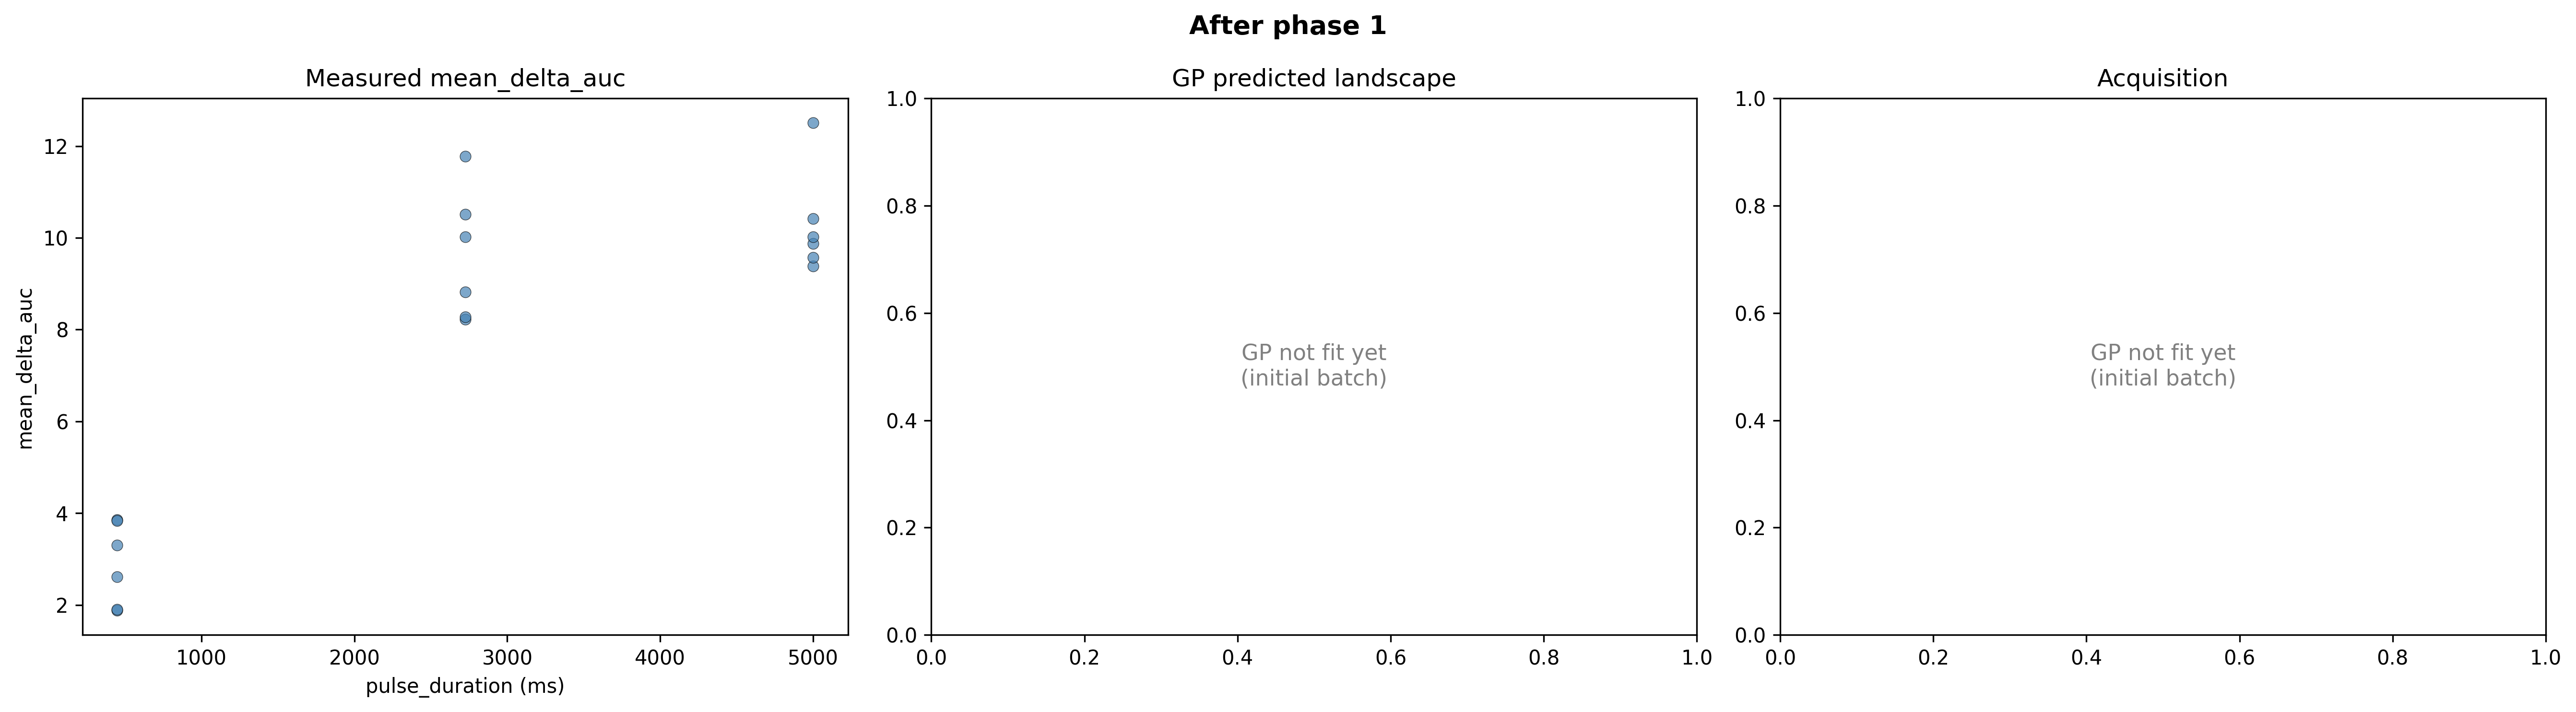


=== ComposedAgent: phase 2/8 ===
[FOVFinderAgent] Phase 1 — selected FOVs:
    A8_0000: 38 cells
    A8_0001: 86 cells
    A8_0002: 168 cells
    A9_0000: 68 cells
    A9_0001: 132 cells
    A9_0002: 191 cells
    A10_0000: 40 cells
    A10_0001: 114 cells
    A10_0002: 173 cells
    A11_0000: 71 cells
    A11_0001: 133 cells
    A11_0002: 174 cells
    A12_0000: 45 cells
    A12_0001: 115 cells
    A12_0002: 192 cells
    B12_0000: 35 cells
    B12_0001: 96 cells
    B12_0002: 188 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: warmup phase 1/1 -- fitting all 1 candidates]
      hill: obj=0.0464, log_evidence=-0.641
    [auc: warmup winner='hill', obj=0.0464]
    [auc: WARMUP COMPLETE -- win frequencies: hill=1.00]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: warmup phase 1/1 -- fitting all 1 candidates]
      hill: obj=0.0513, log_evidence=-2.252
    [frac: warmup winner='hill', obj=0.0513]
    [frac: WARMUP COMPLET

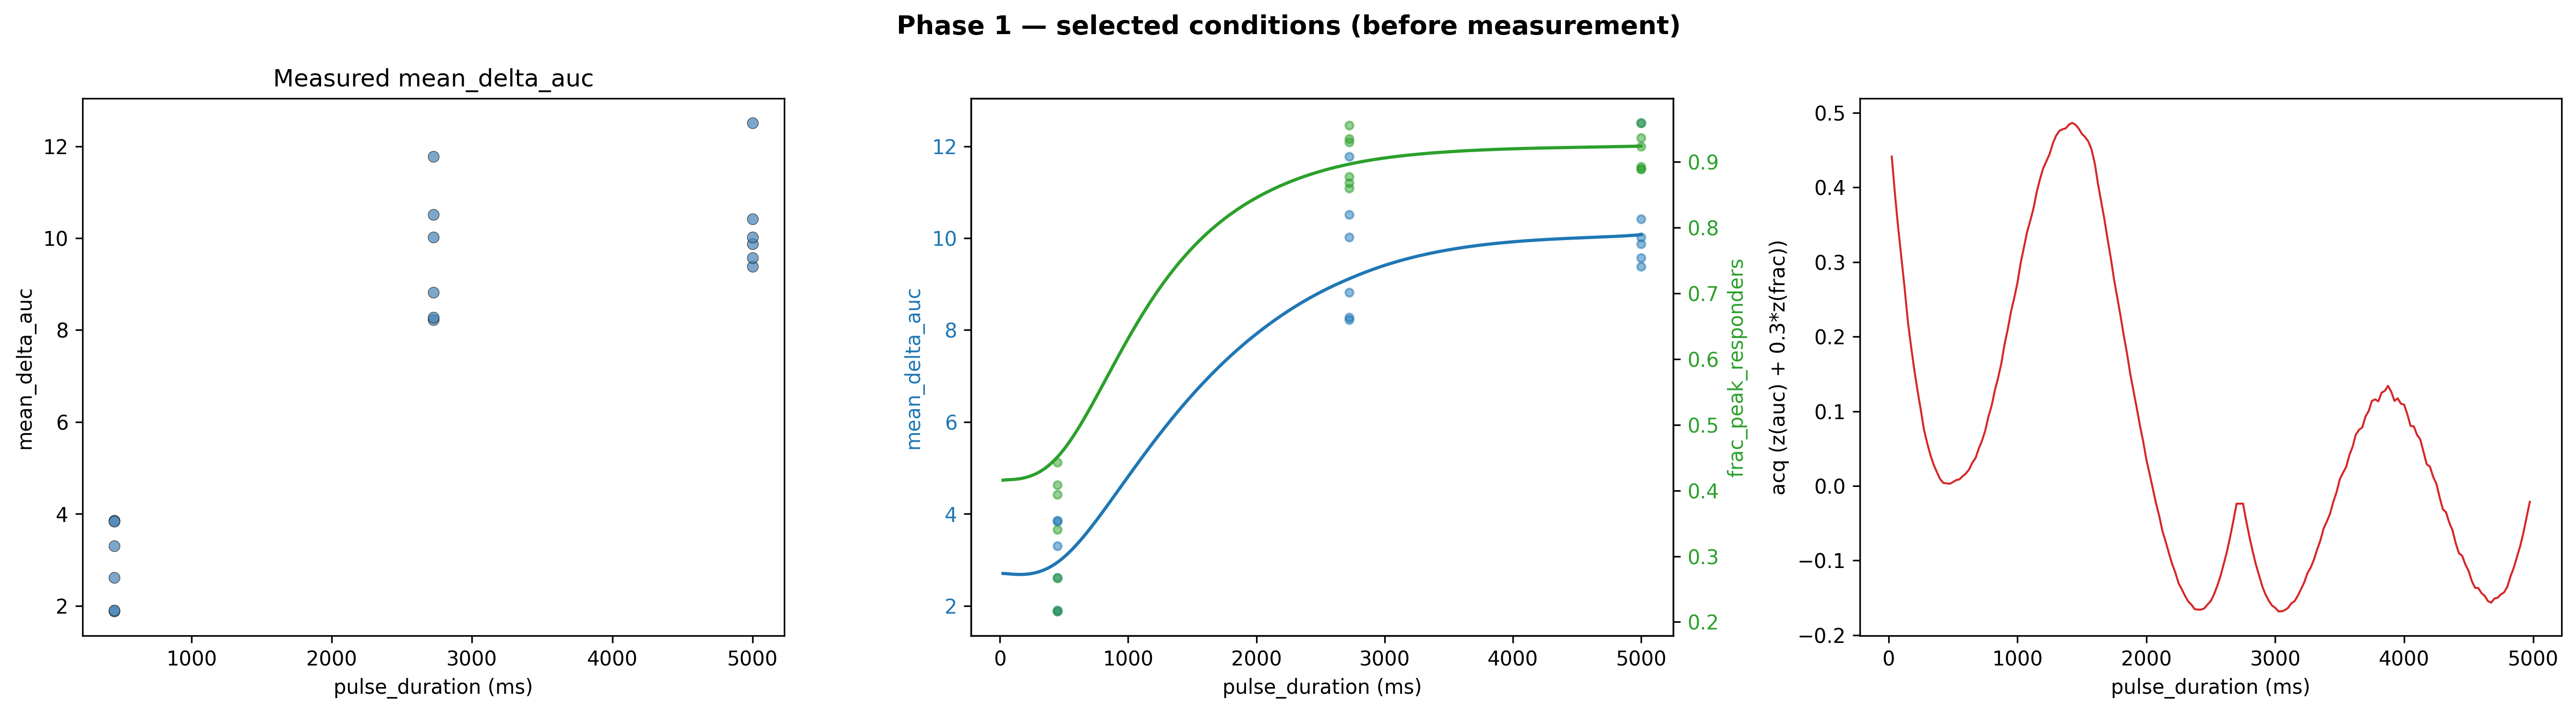

  Created 558 events for phase 1
    Cond 0 (FOVs 18-23): pulse_duration=1425ms
    Cond 1 (FOVs 24-29): pulse_duration=25ms
    Cond 2 (FOVs 30-35): pulse_duration=1000ms
  optoRTK retry summary: 1/1 recovered after re-read


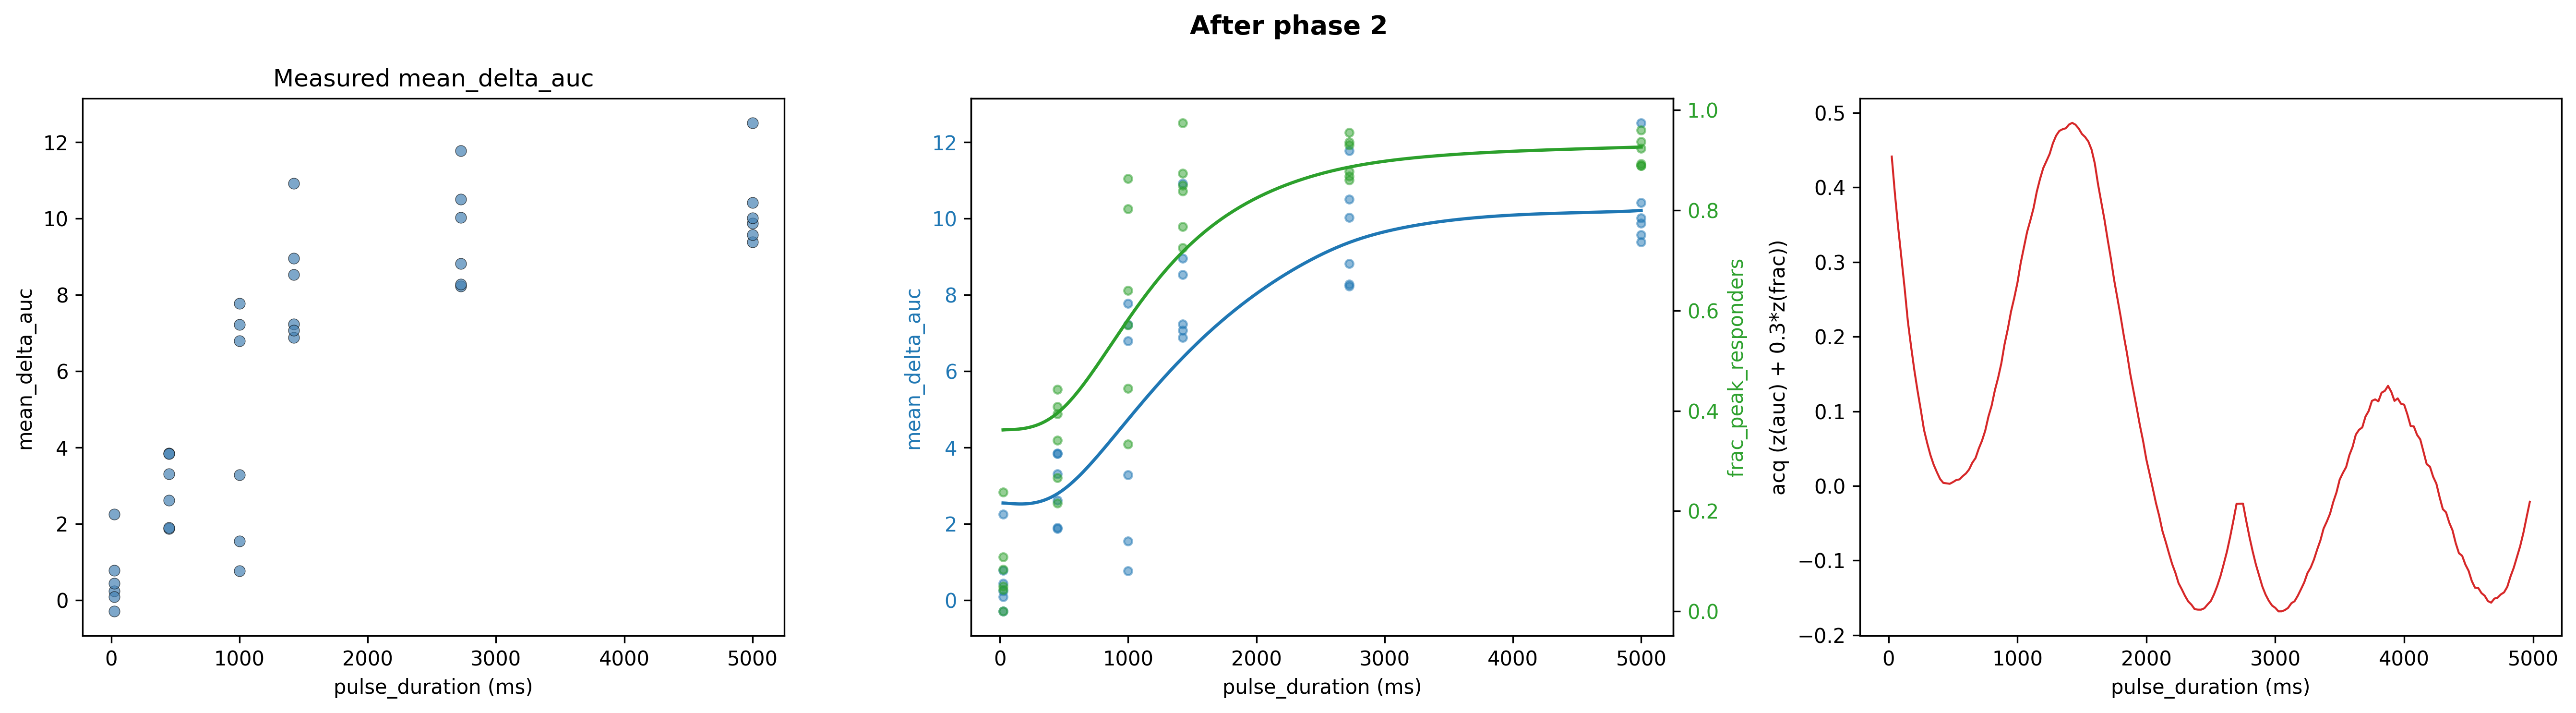


=== ComposedAgent: phase 3/8 ===
[FOVFinderAgent] Phase 2 — selected FOVs:
    B11_0000: 69 cells
    B11_0001: 150 cells
    B11_0002: 171 cells
    B10_0000: 85 cells
    B10_0001: 132 cells
    B10_0002: 149 cells
    B9_0000: 114 cells
    B9_0001: 135 cells
    B9_0002: 167 cells
    B8_0000: 76 cells
    B8_0001: 125 cells
    B8_0002: 180 cells
    B7_0000: 122 cells
    B7_0001: 147 cells
    B7_0002: 154 cells
    B6_0000: 114 cells
    B6_0001: 153 cells
    B6_0002: 169 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=+1.00(n=1))]
    [auc: obj=0.0207 (prev_finite=0.0464) -> reward=+1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+1.00(n=1))]
    [frac: obj=0.0697 (prev_finite=0.0513) -> reward=-1]
  AUC-primary acq stats (frac_w=0.3): min=-0.1293, max=0.7480
  [reusing cached two-task GP fits from earlier in this batch]
  AUC-primary acq stats (frac_w=

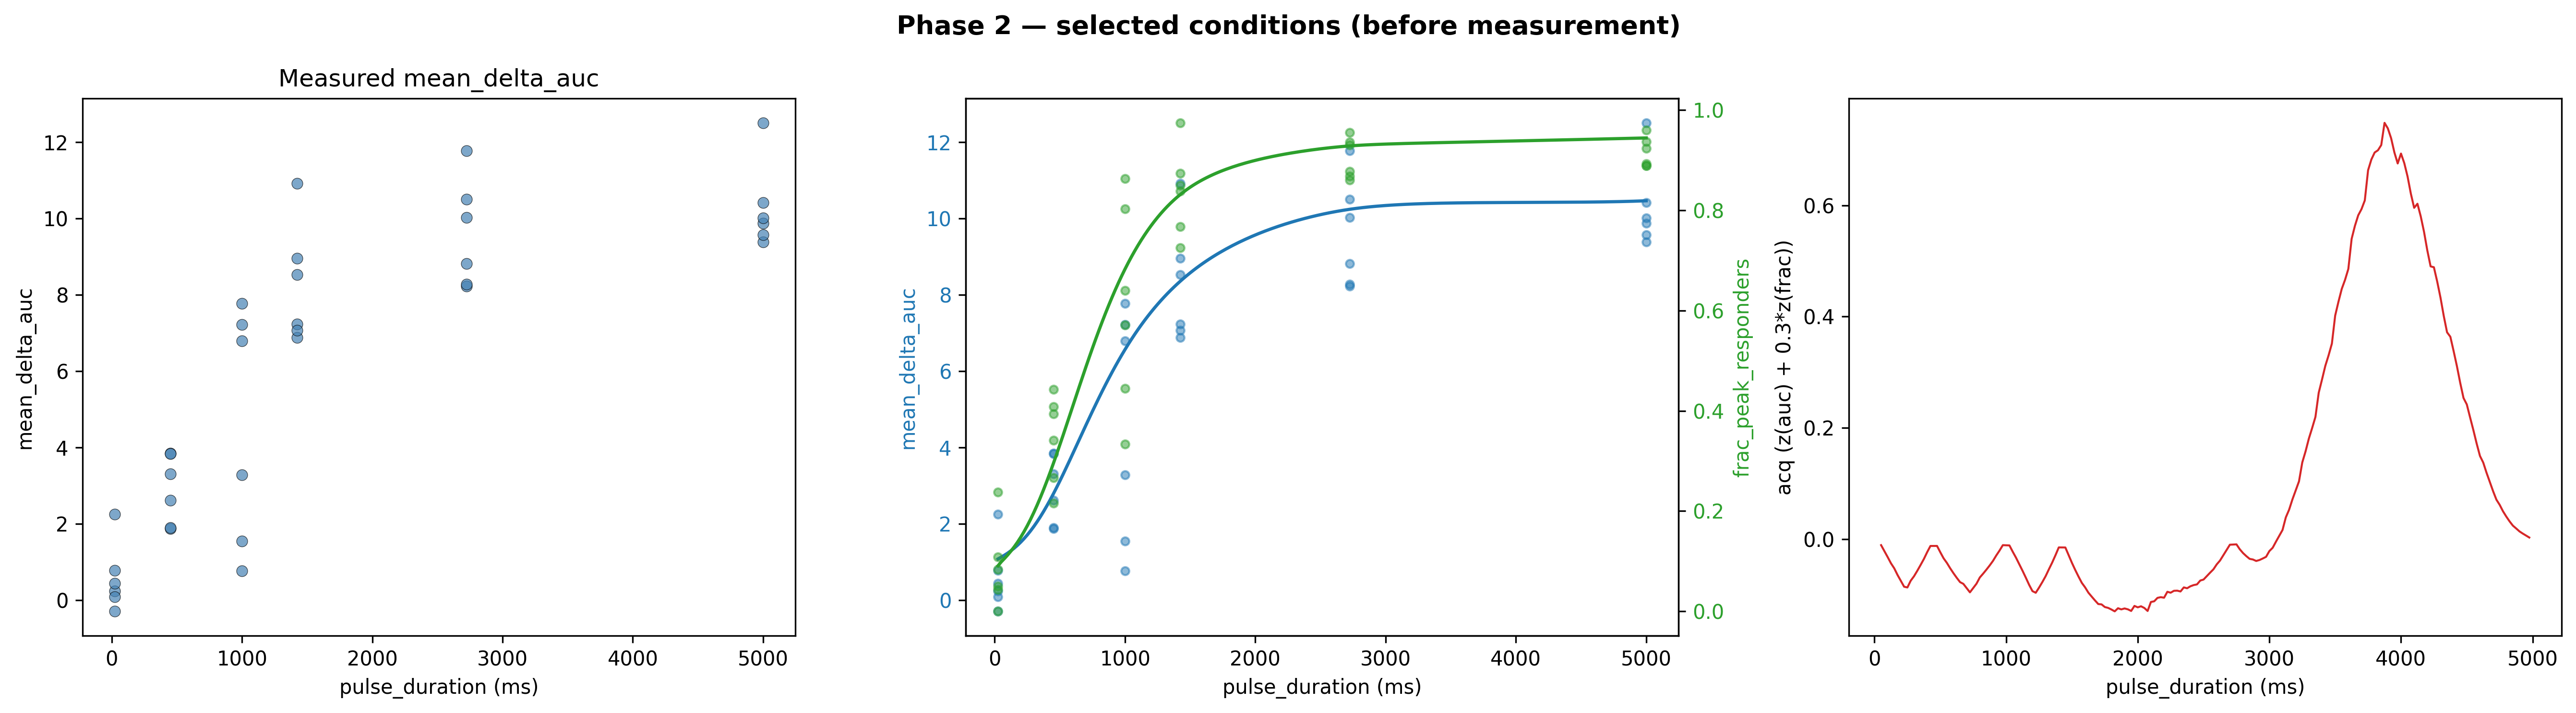

  Created 558 events for phase 2
    Cond 0 (FOVs 36-41): pulse_duration=3875ms
    Cond 1 (FOVs 42-47): pulse_duration=4425ms
    Cond 2 (FOVs 48-53): pulse_duration=3450ms
  optoRTK retry summary: 1/1 recovered after re-read


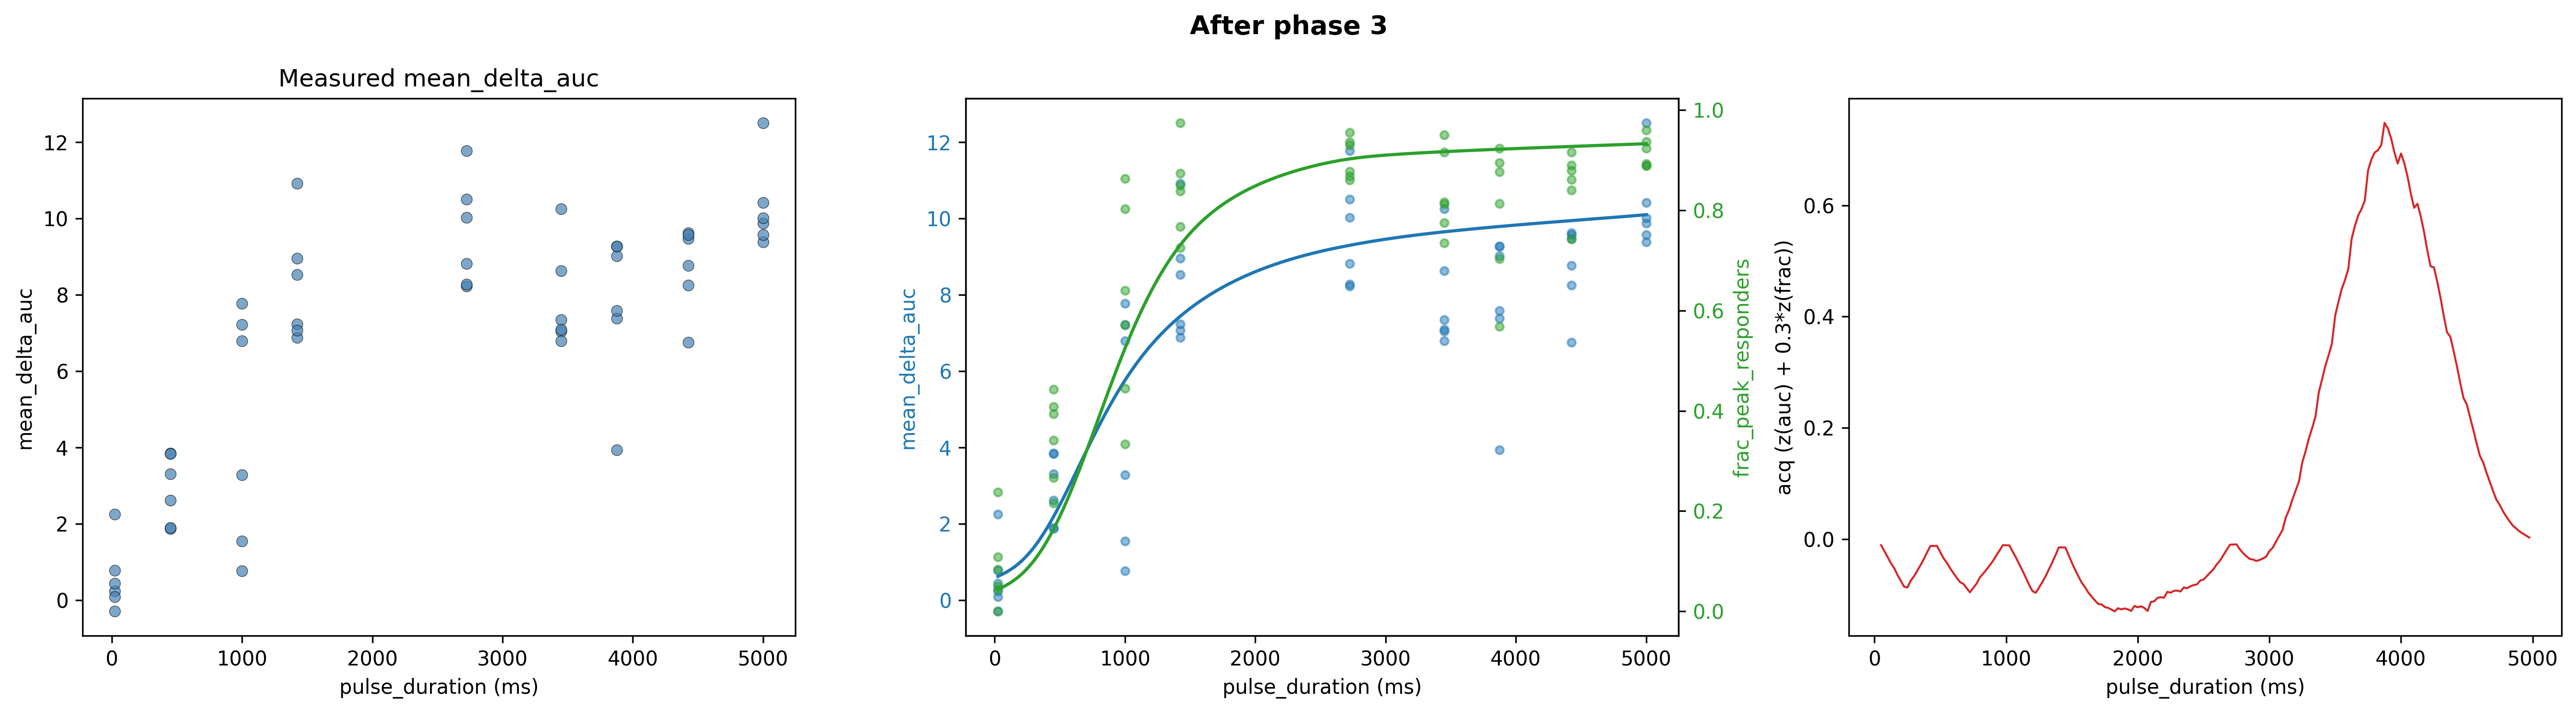


=== ComposedAgent: phase 4/8 ===
[FOVFinderAgent] Phase 3 — selected FOVs:
    B5_0000: 102 cells
    B5_0001: 155 cells
    B5_0002: 173 cells
    B4_0000: 103 cells
    B4_0001: 139 cells
    B4_0002: 165 cells
    B3_0000: 126 cells
    B3_0001: 138 cells
    B3_0002: 181 cells
    B2_0000: 44 cells
    B2_0001: 161 cells
    B2_0002: 194 cells
    C2_0000: 92 cells
    C2_0001: 107 cells
    C2_0002: 160 cells
    C3_0000: 116 cells
    C3_0001: 164 cells
    C3_0002: 188 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=+1.00(n=2))]
    [auc: obj=0.0250 (prev_finite=0.0207) -> reward=-1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.00(n=2))]
    [frac: obj=0.0533 (prev_finite=0.0697) -> reward=+1]
  AUC-primary acq stats (frac_w=0.3): min=-0.2277, max=0.2184
  [reusing cached two-task GP fits from earlier in this batch]
  AUC-primary acq stats (frac_w=0.3):

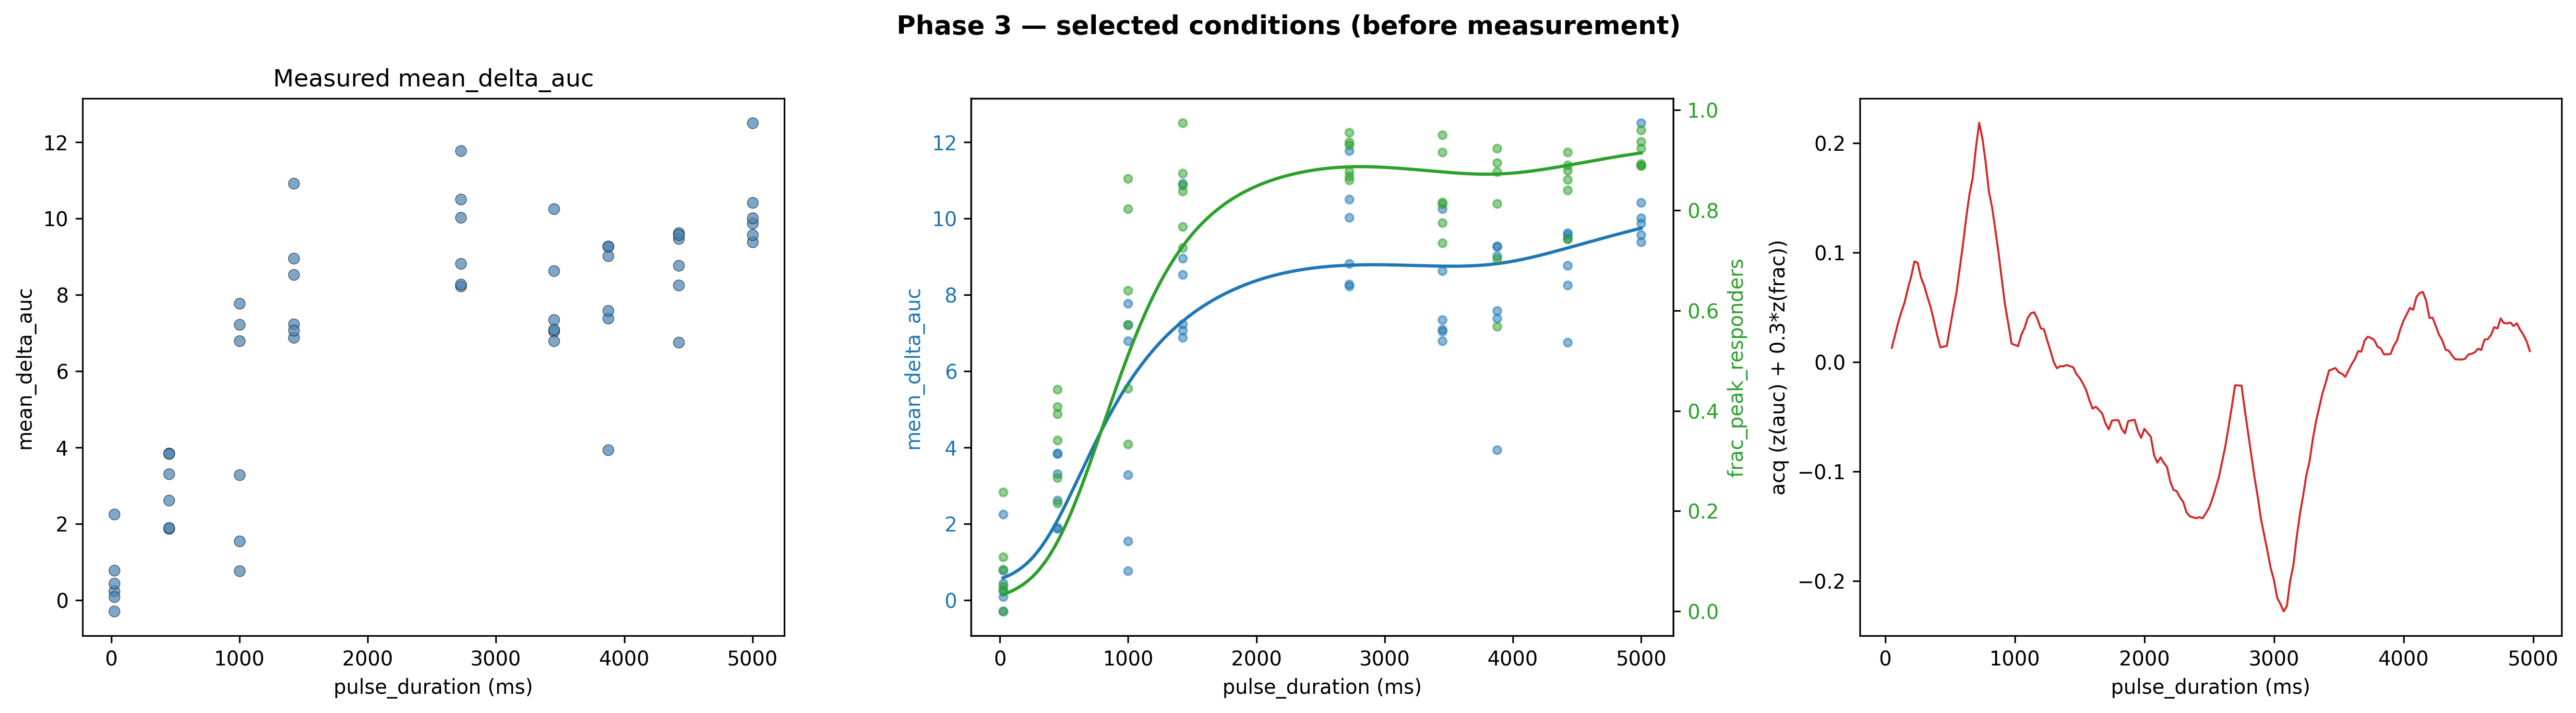

  Created 558 events for phase 3
    Cond 0 (FOVs 54-59): pulse_duration=725ms
    Cond 1 (FOVs 60-65): pulse_duration=250ms
    Cond 2 (FOVs 66-71): pulse_duration=4150ms
  optoRTK retry summary: 1/1 recovered after re-read


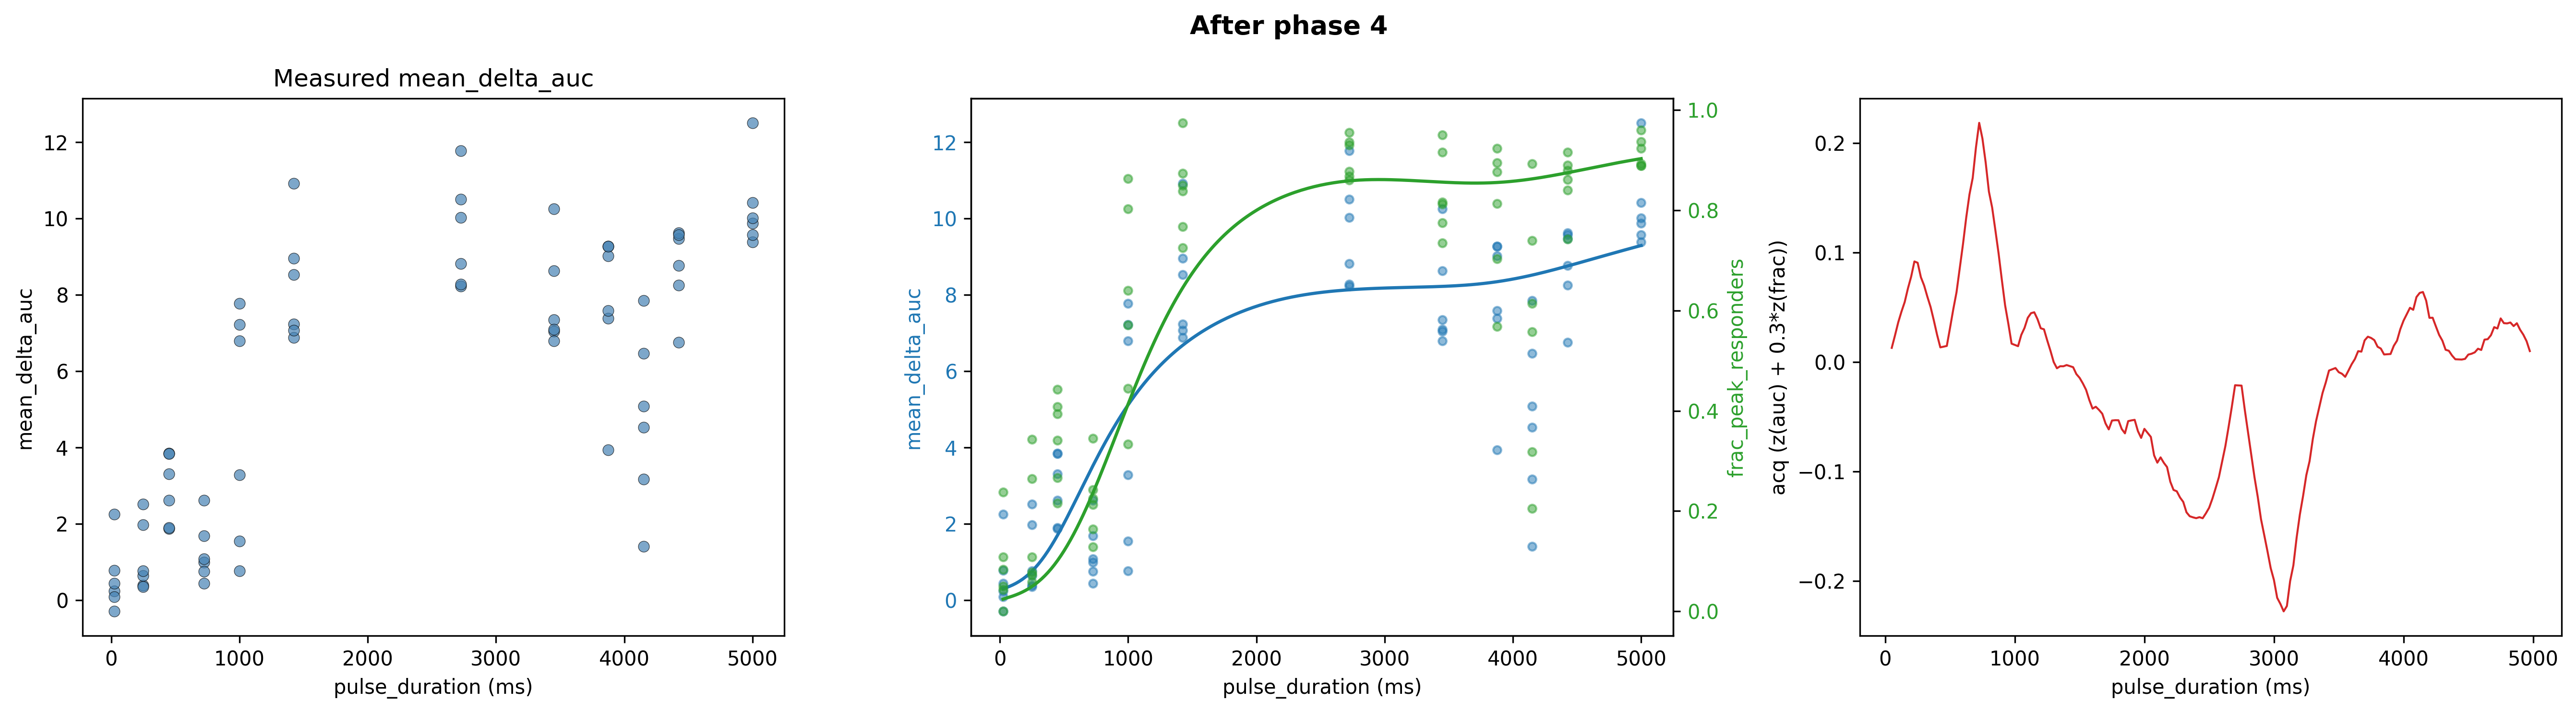


=== ComposedAgent: phase 5/8 ===
[FOVFinderAgent] Phase 4 — selected FOVs:
    C4_0000: 120 cells
    C4_0001: 127 cells
    C4_0002: 167 cells
    C5_0000: 84 cells
    C5_0001: 128 cells
    C5_0002: 168 cells
    C6_0000: 102 cells
    C6_0001: 129 cells
    C6_0002: 143 cells
    C7_0000: 103 cells
    C7_0001: 126 cells
    C7_0002: 159 cells
    C8_0000: 99 cells
    C8_0001: 116 cells
    C8_0002: 157 cells
    C9_0000: 94 cells
    C9_0001: 130 cells
    C9_0002: 144 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=+0.33(n=3))]
    [auc: obj=0.0348 (prev_finite=0.0250) -> reward=-1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.33(n=3))]
    [frac: obj=0.0500 (prev_finite=0.0533) -> reward=+1]
  AUC-primary acq stats (frac_w=0.3): min=-0.0761, max=0.6114
  [reusing cached two-task GP fits from earlier in this batch]
  AUC-primary acq stats (frac_w=0.3): 

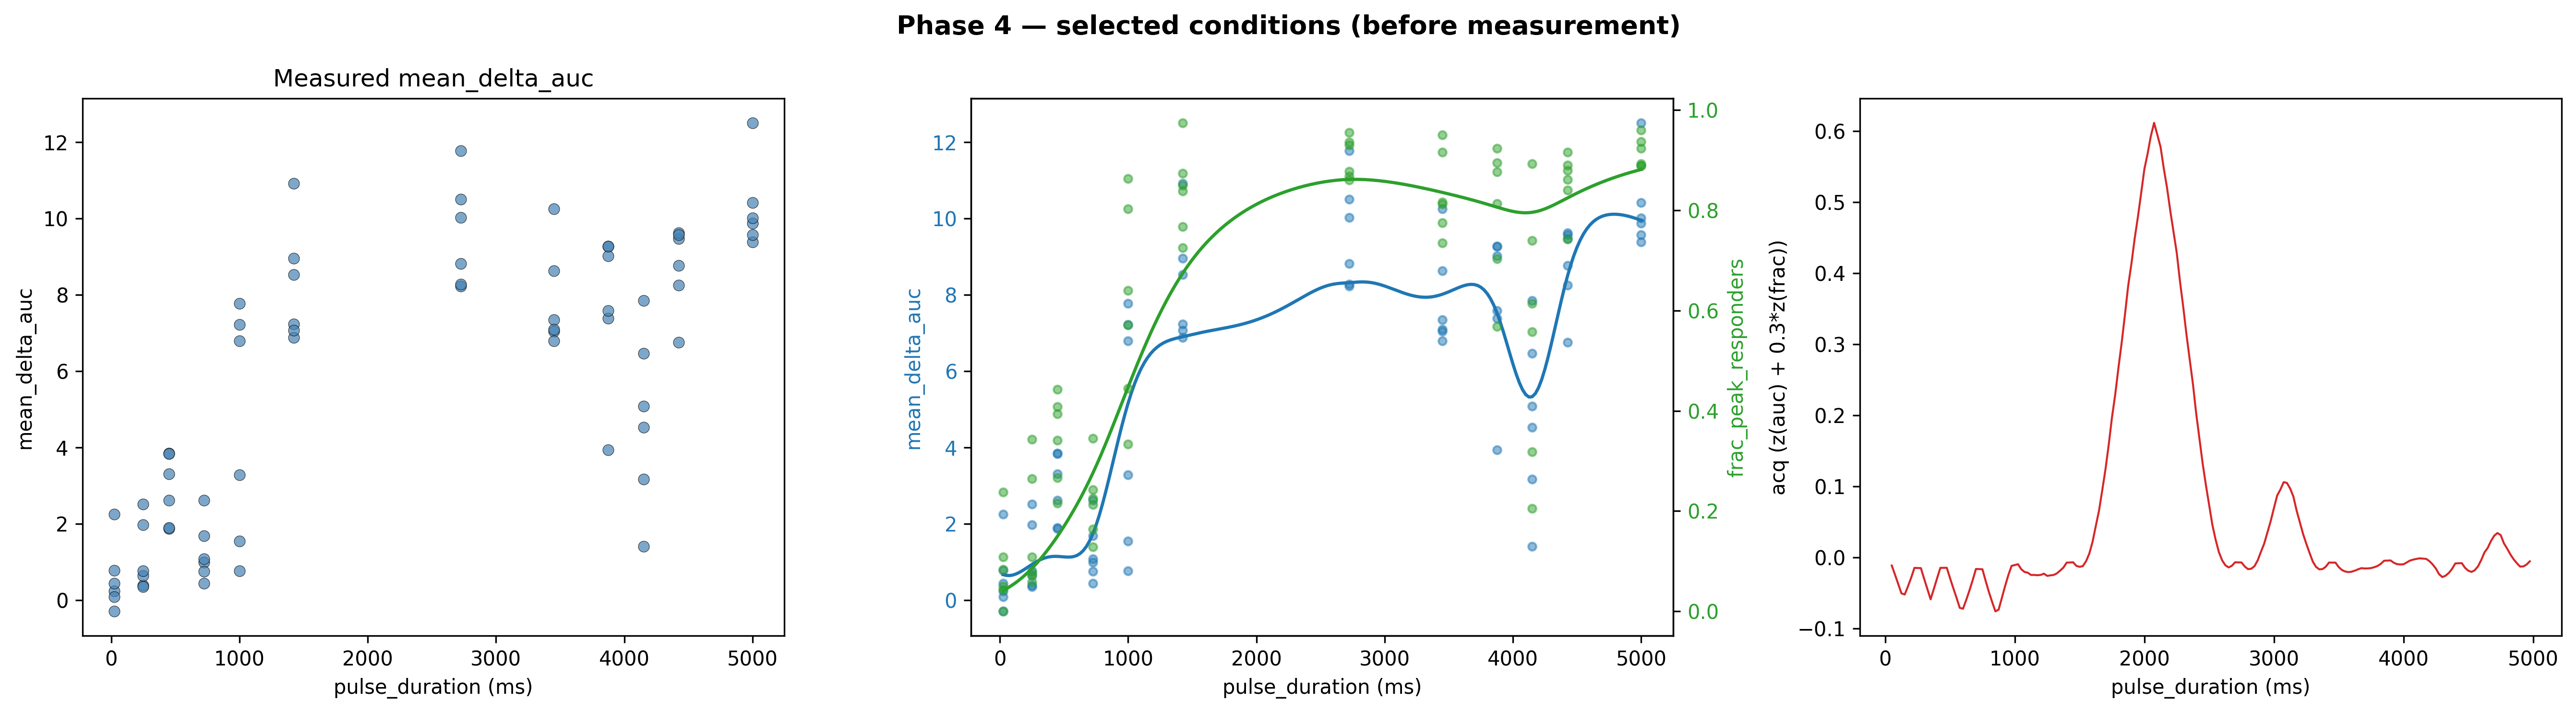

  Created 558 events for phase 4
    Cond 0 (FOVs 72-77): pulse_duration=2075ms
    Cond 1 (FOVs 78-83): pulse_duration=1775ms
    Cond 2 (FOVs 84-89): pulse_duration=2350ms
  optoRTK retry summary: 1/1 recovered after re-read


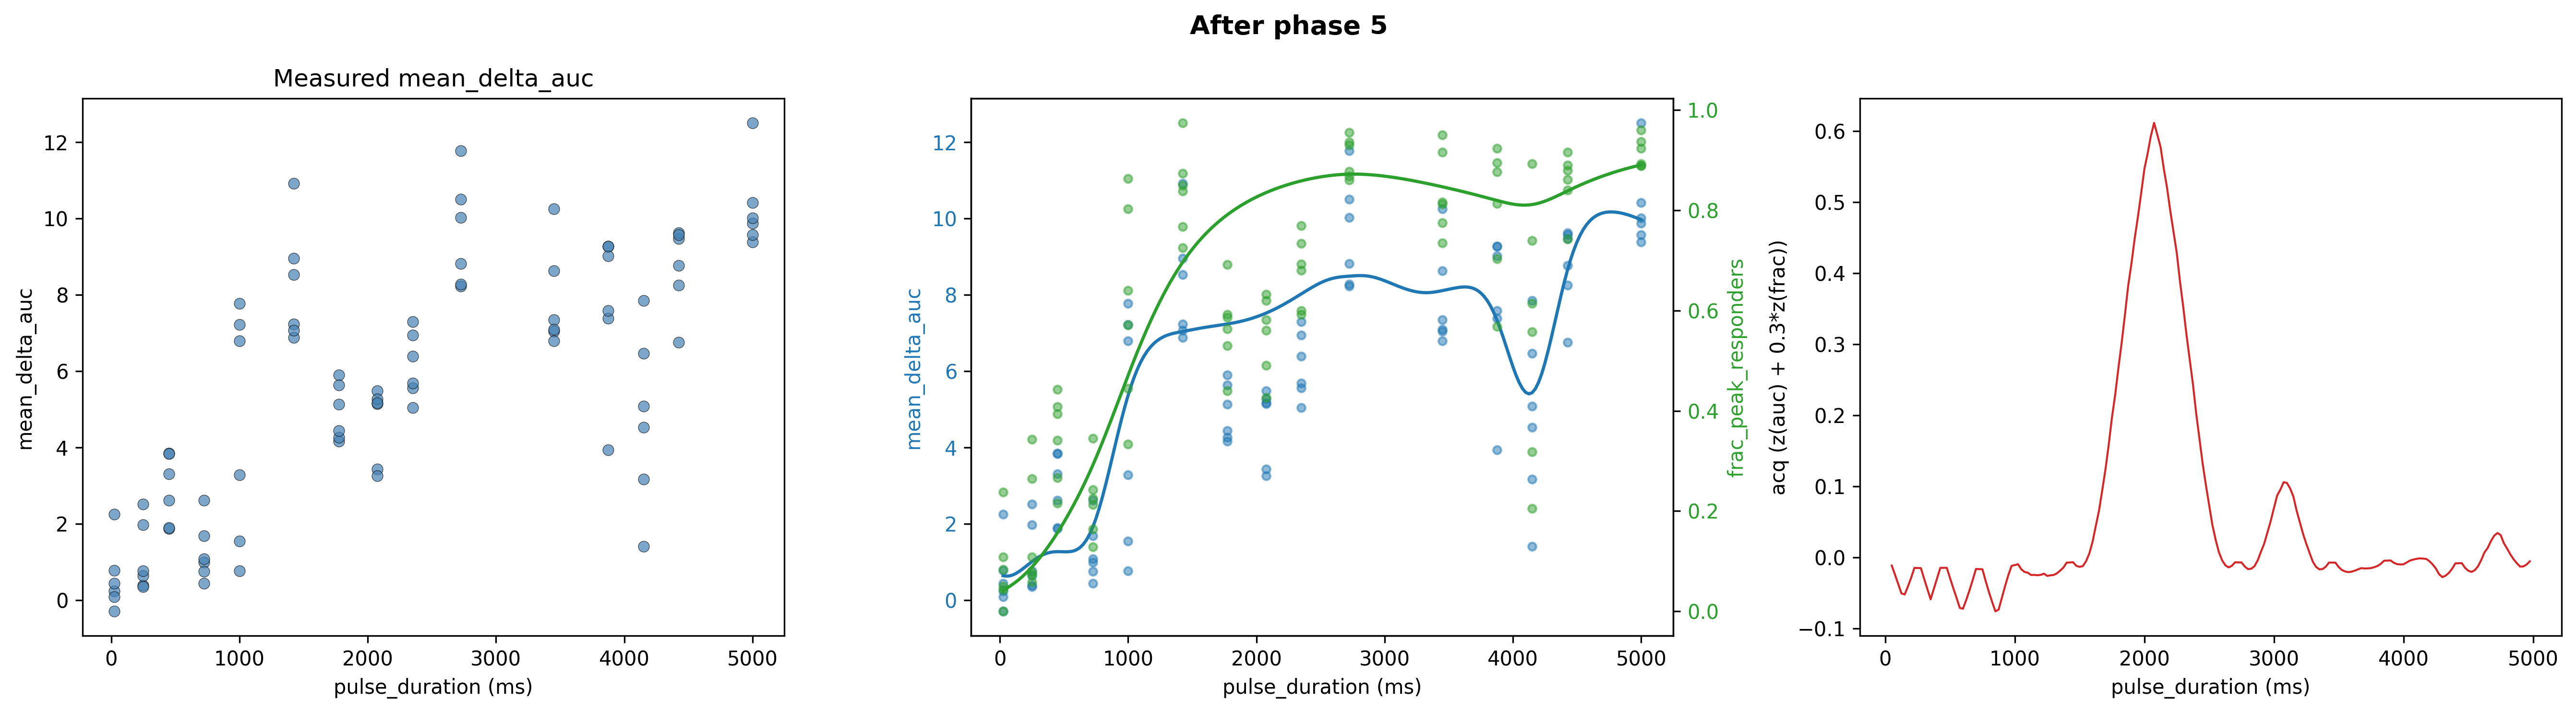


=== ComposedAgent: phase 6/8 ===
[FOVFinderAgent] Phase 5 — selected FOVs:
    C10_0000: 107 cells
    C10_0001: 127 cells
    C10_0002: 146 cells
    C11_0000: 93 cells
    C11_0001: 114 cells
    C11_0002: 136 cells
    C12_0000: 53 cells
    C12_0001: 87 cells
    C12_0002: 150 cells
    D12_0000: 41 cells
    D12_0001: 73 cells
    D12_0002: 145 cells
    D11_0000: 43 cells
    D11_0001: 121 cells
    D11_0002: 154 cells
    D10_0000: 107 cells
    D10_0001: 132 cells
    D10_0002: 171 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=+0.00(n=4))]
    [auc: obj=0.0355 (prev_finite=0.0348) -> reward=-1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.50(n=4))]
    [frac: obj=0.0399 (prev_finite=0.0500) -> reward=+1]
  AUC-primary acq stats (frac_w=0.3): min=-0.0653, max=0.3374
  [reusing cached two-task GP fits from earlier in this batch]
  AUC-primary acq stats

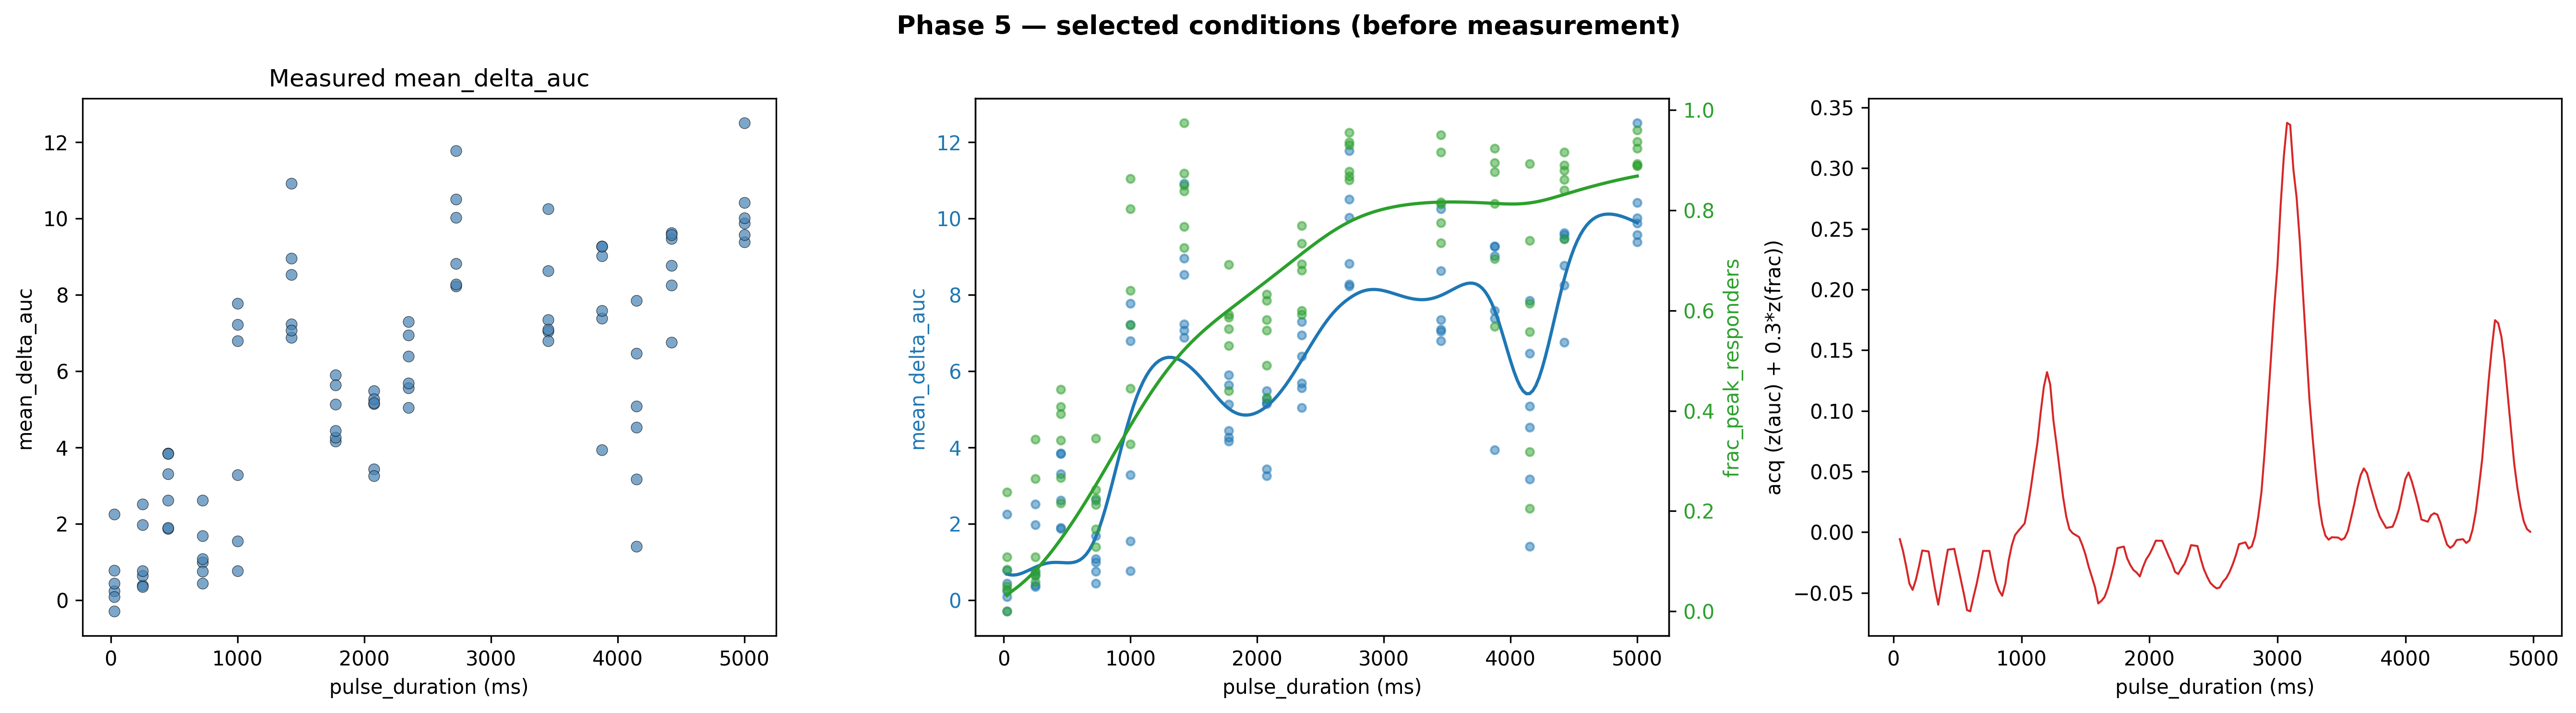

  Created 558 events for phase 5
    Cond 0 (FOVs 90-95): pulse_duration=3075ms
    Cond 1 (FOVs 96-101): pulse_duration=4725ms
    Cond 2 (FOVs 102-107): pulse_duration=1200ms
  optoRTK retry summary: 1/1 recovered after re-read


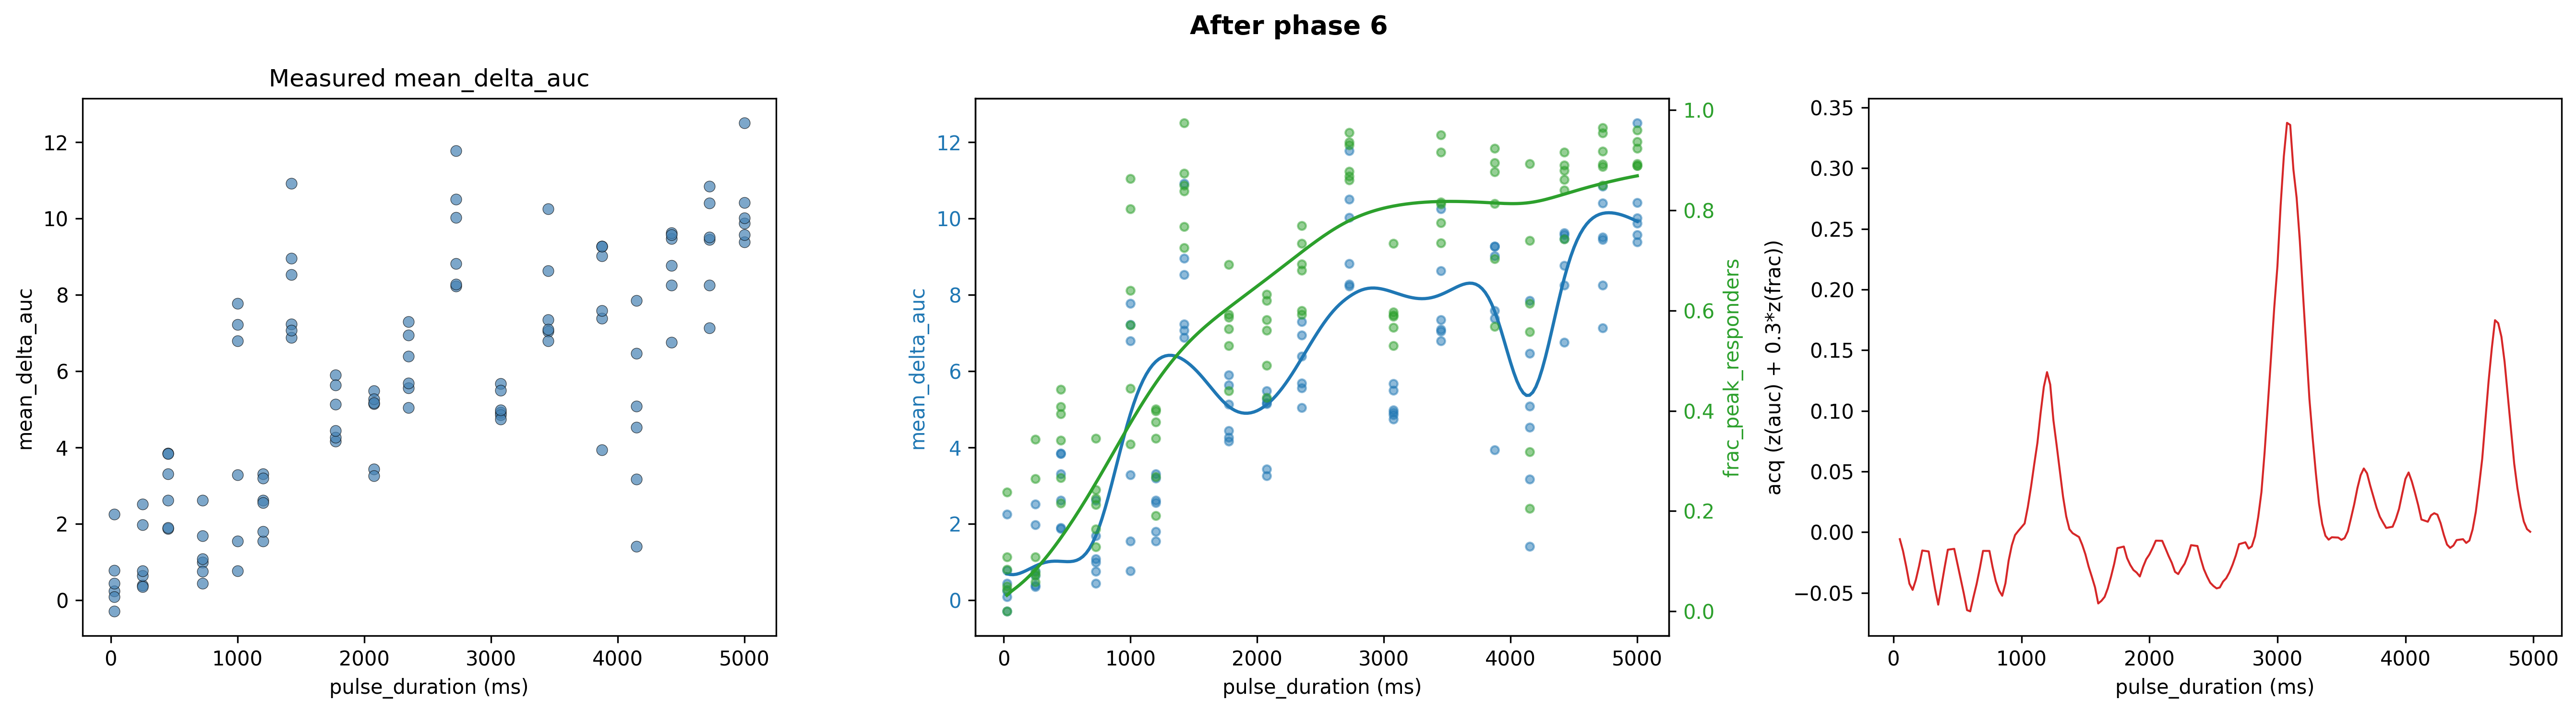


=== ComposedAgent: phase 7/8 ===
[FOVFinderAgent] Phase 6 — selected FOVs:
    D9_0000: 62 cells
    D9_0001: 109 cells
    D9_0002: 163 cells
    D8_0000: 77 cells
    D8_0001: 130 cells
    D8_0002: 168 cells
    D7_0000: 40 cells
    D7_0001: 116 cells
    D7_0002: 148 cells
    D6_0000: 103 cells
    D6_0001: 114 cells
    D6_0002: 143 cells
    D5_0000: 91 cells
    D5_0001: 135 cells
    D5_0002: 204 cells
    D4_0000: 38 cells
    D4_0001: 146 cells
    D4_0002: 158 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=-0.20(n=5))]
    [auc: obj=0.0358 (prev_finite=0.0355) -> reward=-1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.60(n=5))]
    [frac: obj=0.0267 (prev_finite=0.0399) -> reward=+1]
  AUC-primary acq stats (frac_w=0.3): min=-0.0526, max=0.1495
  [reusing cached two-task GP fits from earlier in this batch]
  AUC-primary acq stats (frac_w=0.3): mi

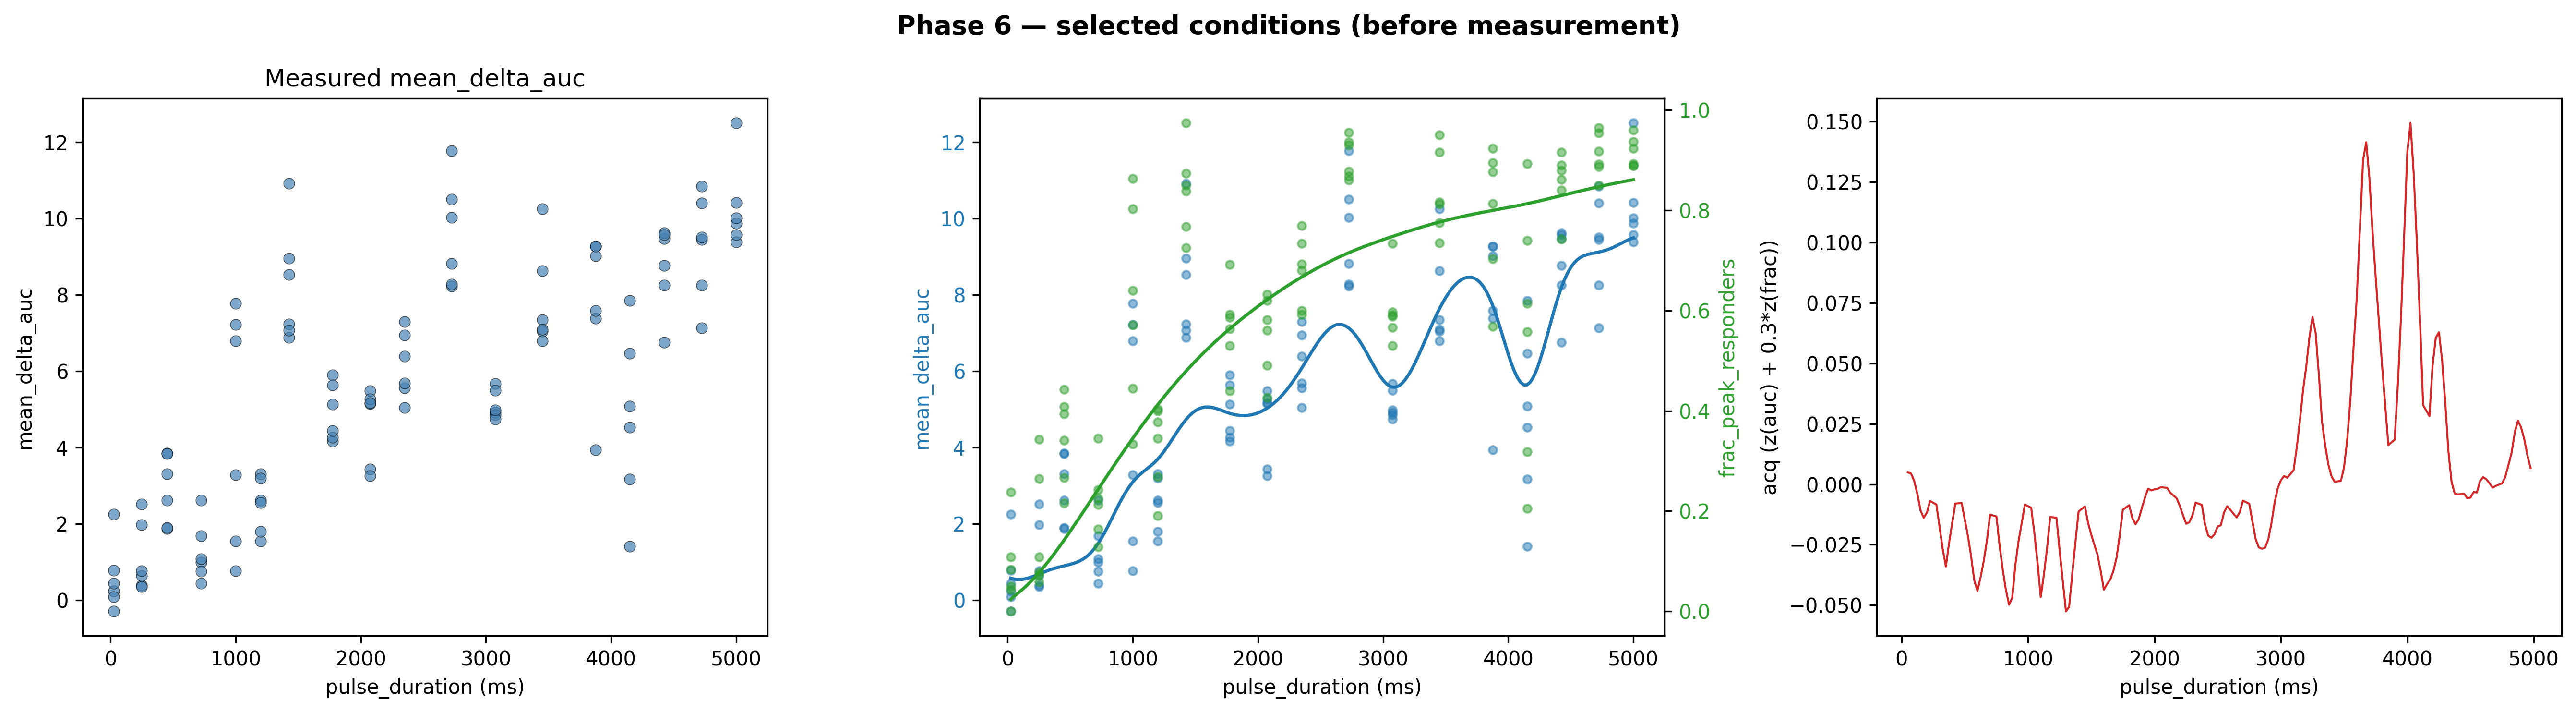

  Created 558 events for phase 6
    Cond 0 (FOVs 108-113): pulse_duration=4025ms
    Cond 1 (FOVs 114-119): pulse_duration=3675ms
    Cond 2 (FOVs 120-125): pulse_duration=3250ms
  optoRTK retry summary: 1/1 recovered after re-read


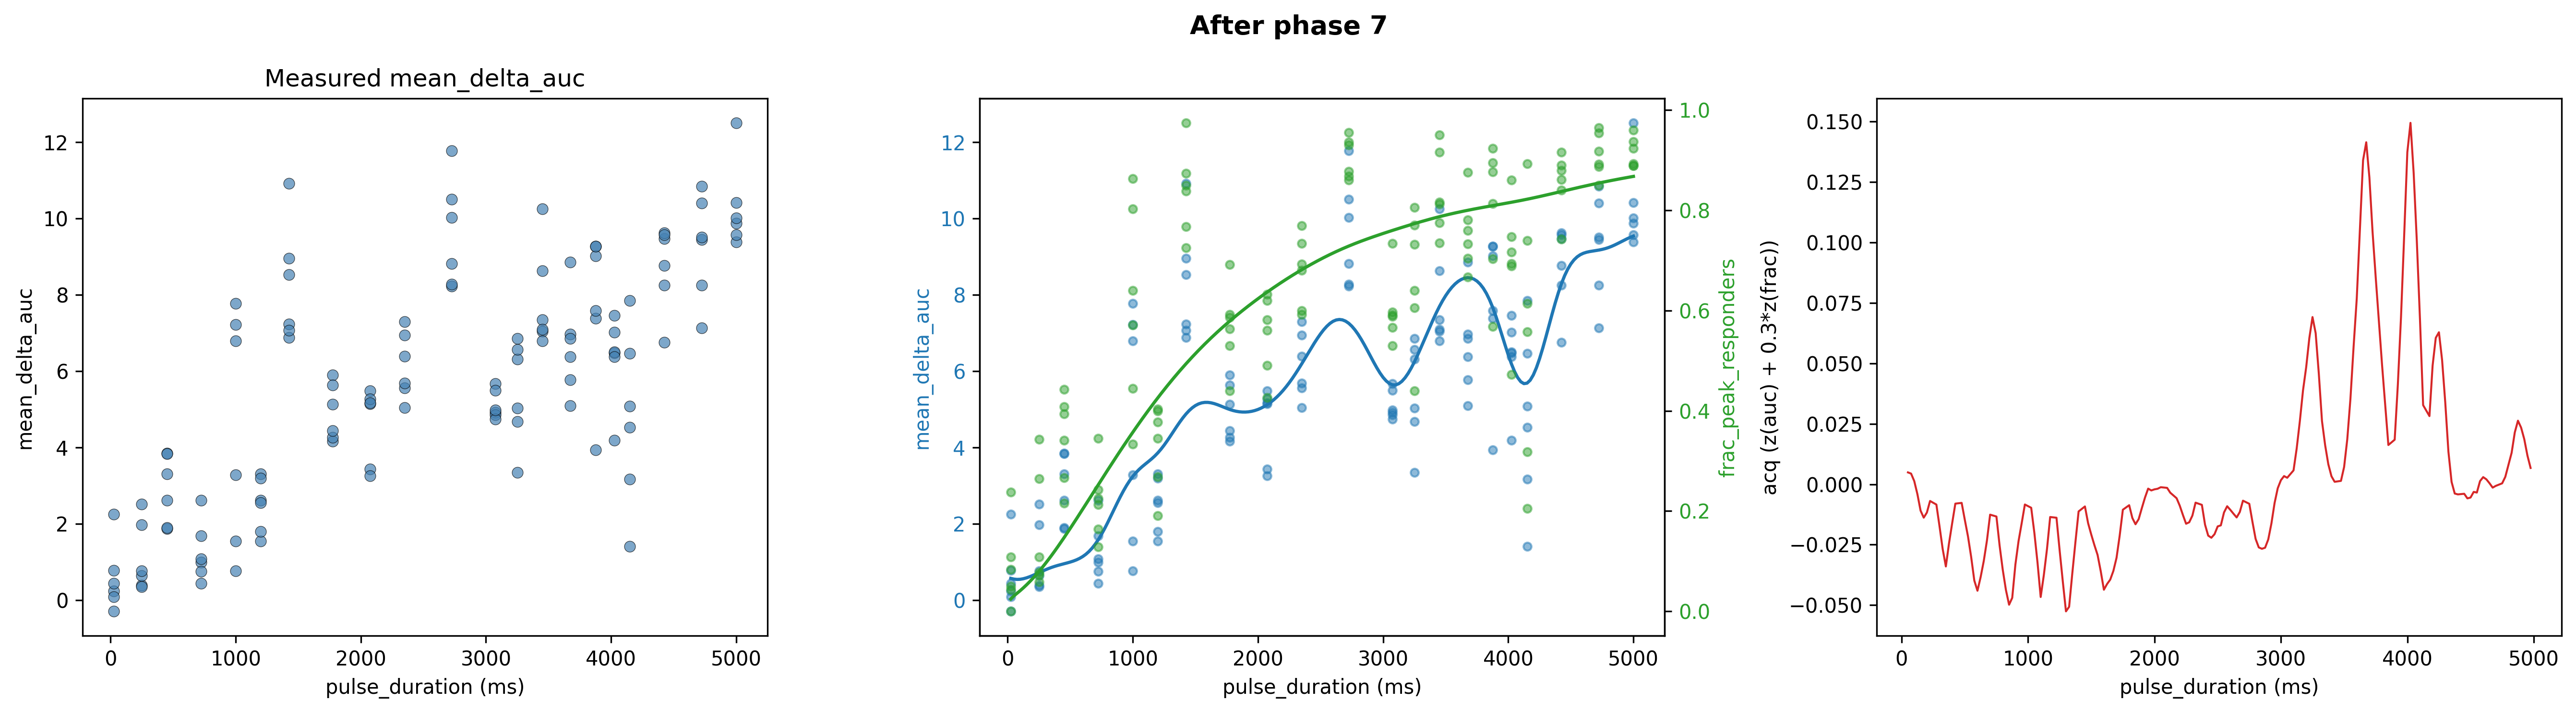


=== ComposedAgent: phase 8/8 ===
[FOVFinderAgent] Phase 7 — selected FOVs:
    D3_0000: 91 cells
    D3_0001: 150 cells
    D3_0002: 198 cells
    D2_0000: 61 cells
    D2_0001: 97 cells
    D2_0002: 155 cells
    E2_0000: 60 cells
    E2_0001: 115 cells
    E2_0002: 164 cells
    E3_0000: 45 cells
    E3_0001: 83 cells
    E3_0002: 169 cells
    E4_0000: 77 cells
    E4_0001: 126 cells
    E4_0002: 140 cells
    E5_0000: 89 cells
    E5_0001: 131 cells
    E5_0002: 157 cells
  Fitting task = 'auc' (column = 'mean_delta_auc', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=-0.33(n=6))]
    [auc: obj=0.0399 (prev_finite=0.0358) -> reward=-1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.67(n=6))]
    [frac: obj=0.0282 (prev_finite=0.0267) -> reward=-1]
  AUC-primary acq stats (frac_w=0.3): min=-0.0675, max=0.1222
  [reusing cached two-task GP fits from earlier in this batch]
  AUC-primary acq stats (frac_w=0.3): min=-

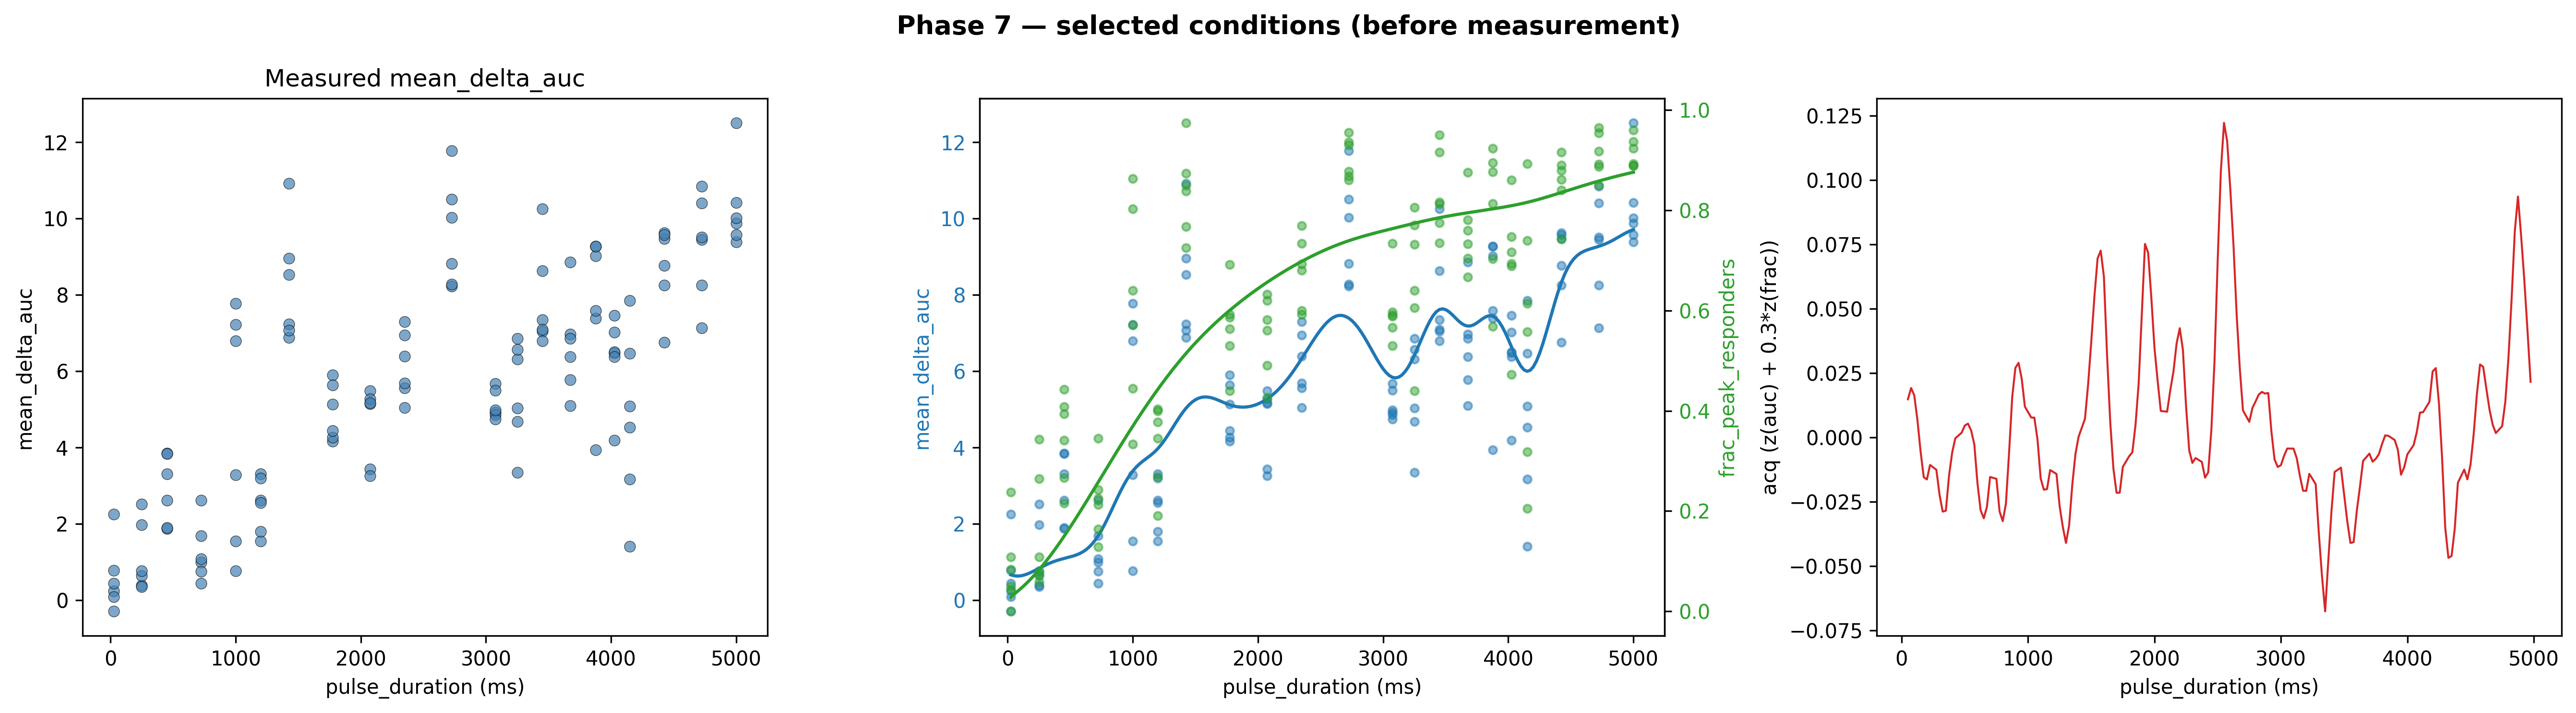

  Created 558 events for phase 7
    Cond 0 (FOVs 126-131): pulse_duration=2550ms
    Cond 1 (FOVs 132-137): pulse_duration=4875ms
    Cond 2 (FOVs 138-143): pulse_duration=1575ms
  optoRTK retry summary: 1/1 recovered after re-read


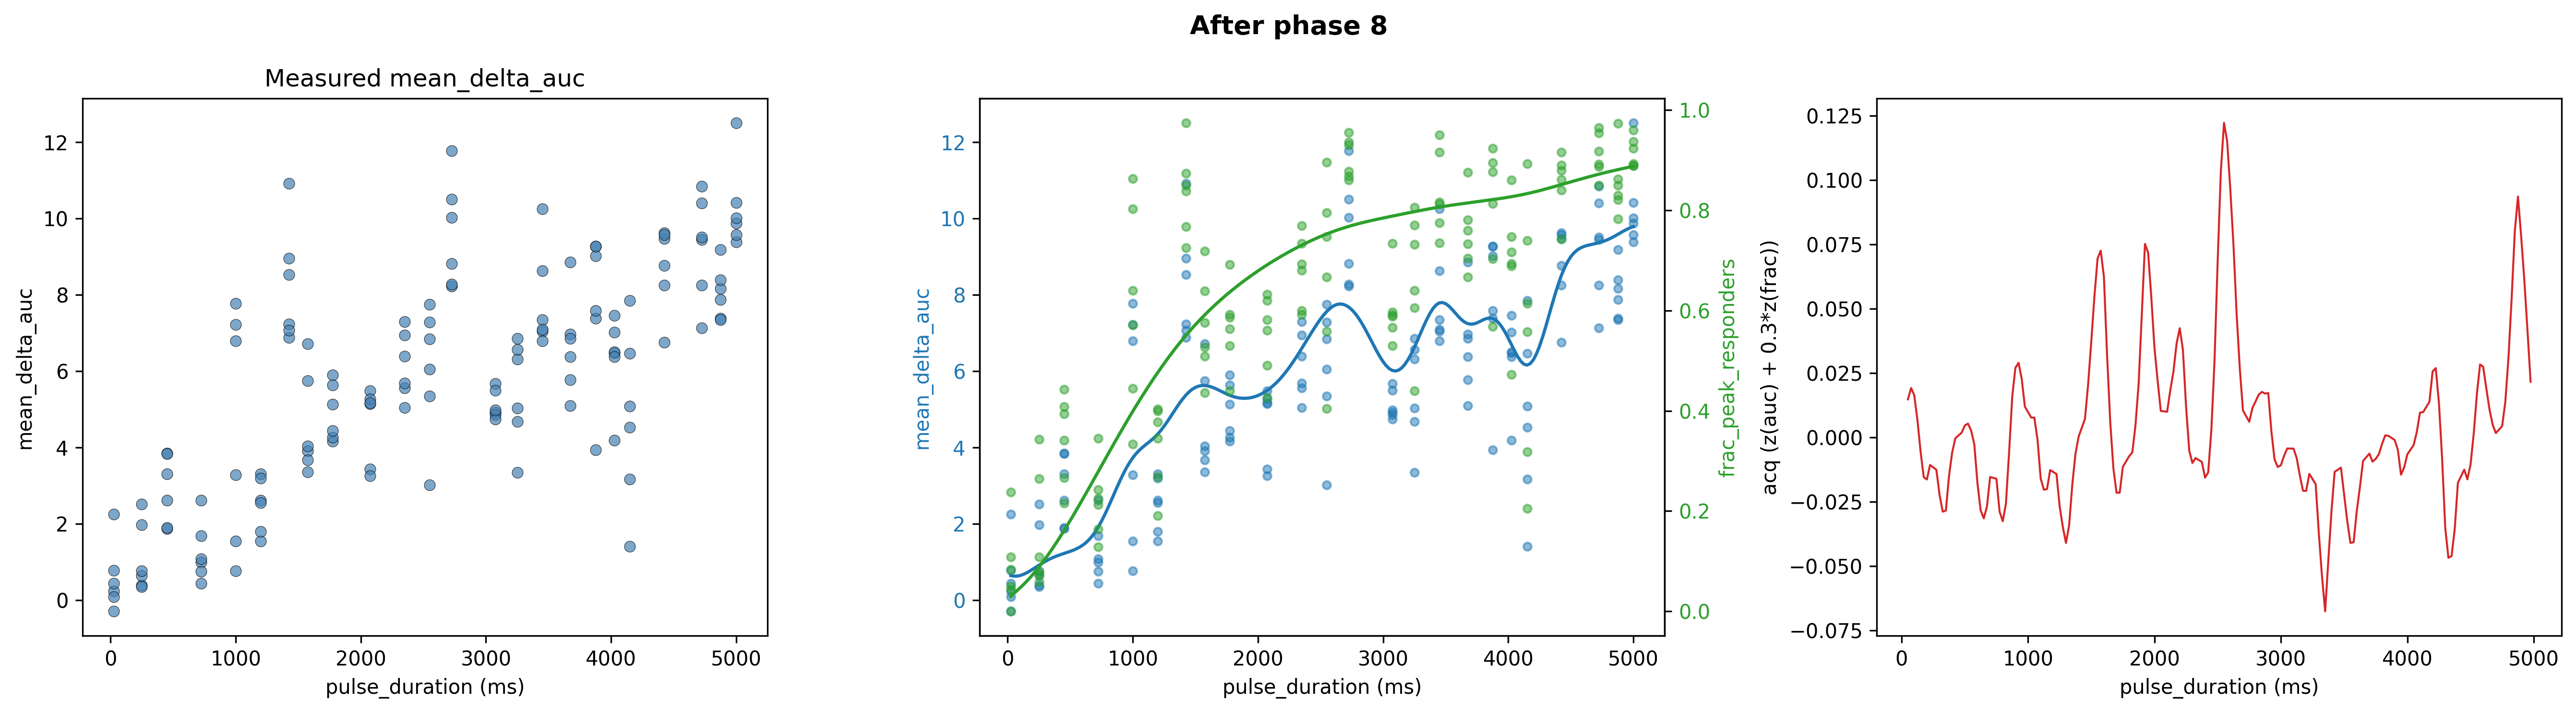

In [9]:
# Disconnect napari live view so it does not interfere with the acquisition engine.
try:
    mm_wdg._core_link.cleanup()
except Exception:
    pass

composed_agent.run()

In [10]:
# Post-processing: merge per-FOV tracks into a single dataframe.
utils.generate_exp_data_from_tracks(path)

## Visualise dose-response and hypothesis evidence

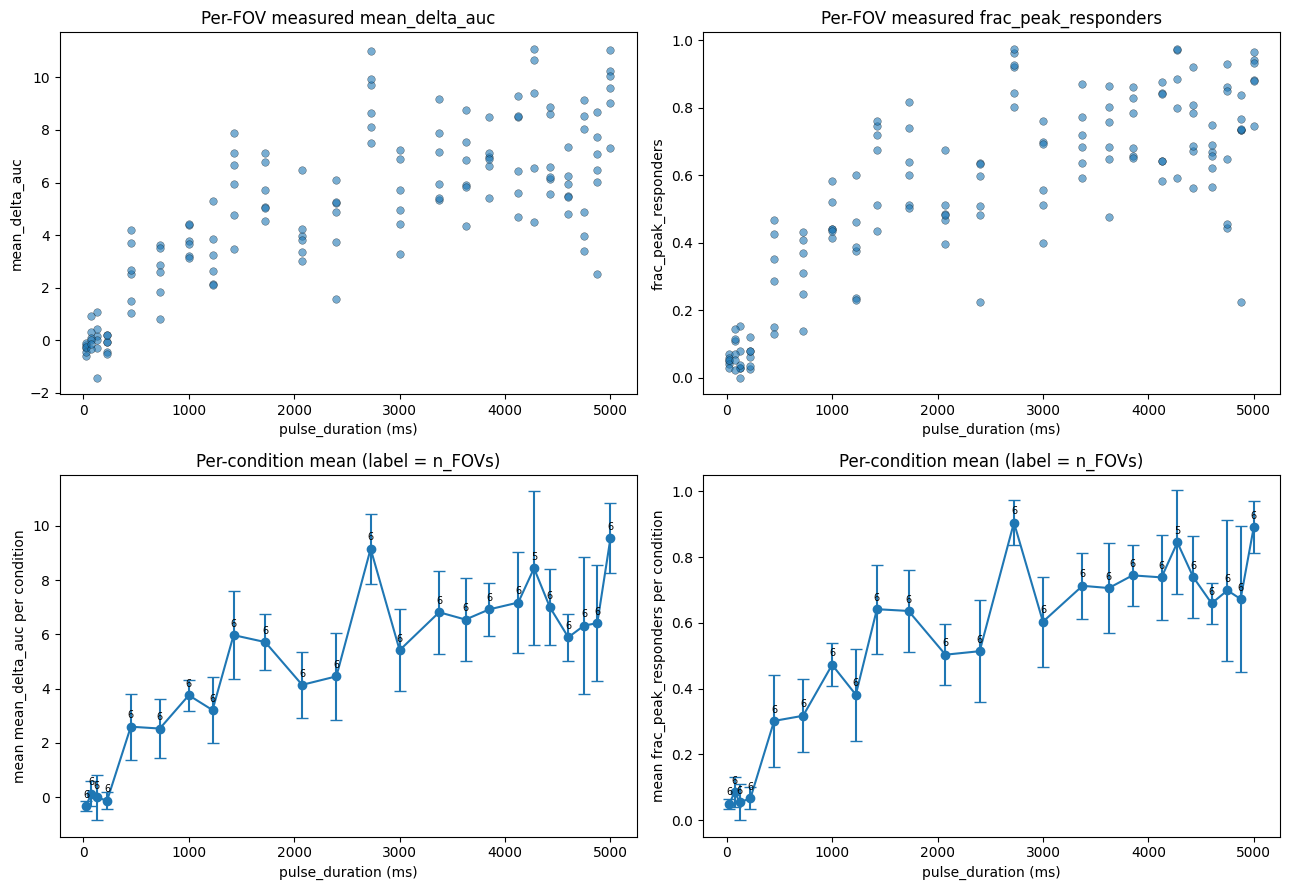

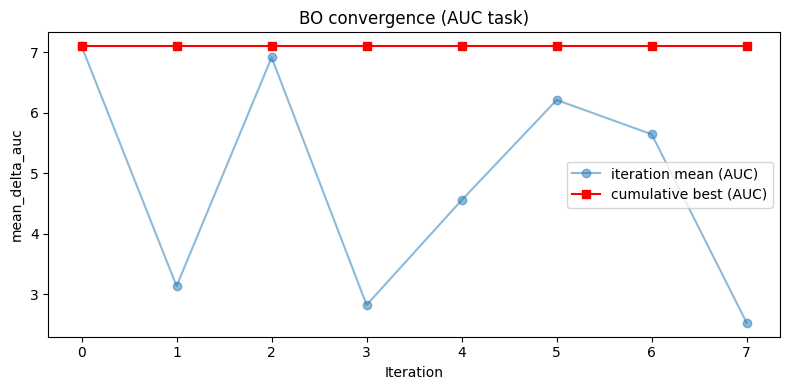

In [19]:
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    for col, task_col, ylabel in [
        (0, "mean_delta_auc", "mean_delta_auc"),
        (1, "frac_peak_responders", "frac_peak_responders"),
    ]:
        # Top row: per-FOV scatter
        axes[0, col].scatter(
            df["pulse_duration"],
            df[task_col],
            alpha=0.6,
            s=30,
            edgecolors="k",
            linewidths=0.3,
        )
        axes[0, col].set_xlabel("pulse_duration (ms)")
        axes[0, col].set_ylabel(ylabel)
        axes[0, col].set_title(f"Per-FOV measured {ylabel}")

        # Bottom row: per-condition mean +/- std
        cond_agg = (
            df.groupby("pulse_duration")
            .agg(
                mean_y=(task_col, "mean"),
                std_y=(task_col, "std"),
                n_fovs=(task_col, "count"),
            )
            .reset_index()
        )
        axes[1, col].errorbar(
            cond_agg["pulse_duration"],
            cond_agg["mean_y"],
            yerr=cond_agg["std_y"].fillna(0.0),
            fmt="o-",
            capsize=4,
        )
        axes[1, col].set_xlabel("pulse_duration (ms)")
        axes[1, col].set_ylabel(f"mean {ylabel} per condition")
        axes[1, col].set_title("Per-condition mean (label = n_FOVs)")
        for _, r in cond_agg.iterrows():
            axes[1, col].annotate(
                int(r["n_fovs"]),
                (r["pulse_duration"], r["mean_y"]),
                textcoords="offset points",
                xytext=(0, 6),
                ha="center",
                fontsize=7,
            )
    axes[1, 1].set_ylim(-0.05, 1.05)  # frac_peak_responders is bounded
    plt.tight_layout()
    plt.show()

    if agent._iteration_means:
        fig, ax = plt.subplots(figsize=(8, 4))
        means = np.array(agent._iteration_means)
        ax.plot(means, "o-", alpha=0.5, label="iteration mean (AUC)")
        ax.plot(
            np.maximum.accumulate(means),
            "s-",
            color="red",
            label="cumulative best (AUC)",
        )
        ax.set_xlabel("Iteration")
        ax.set_ylabel("mean_delta_auc")
        ax.set_title("BO convergence (AUC task)")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No data collected yet.")

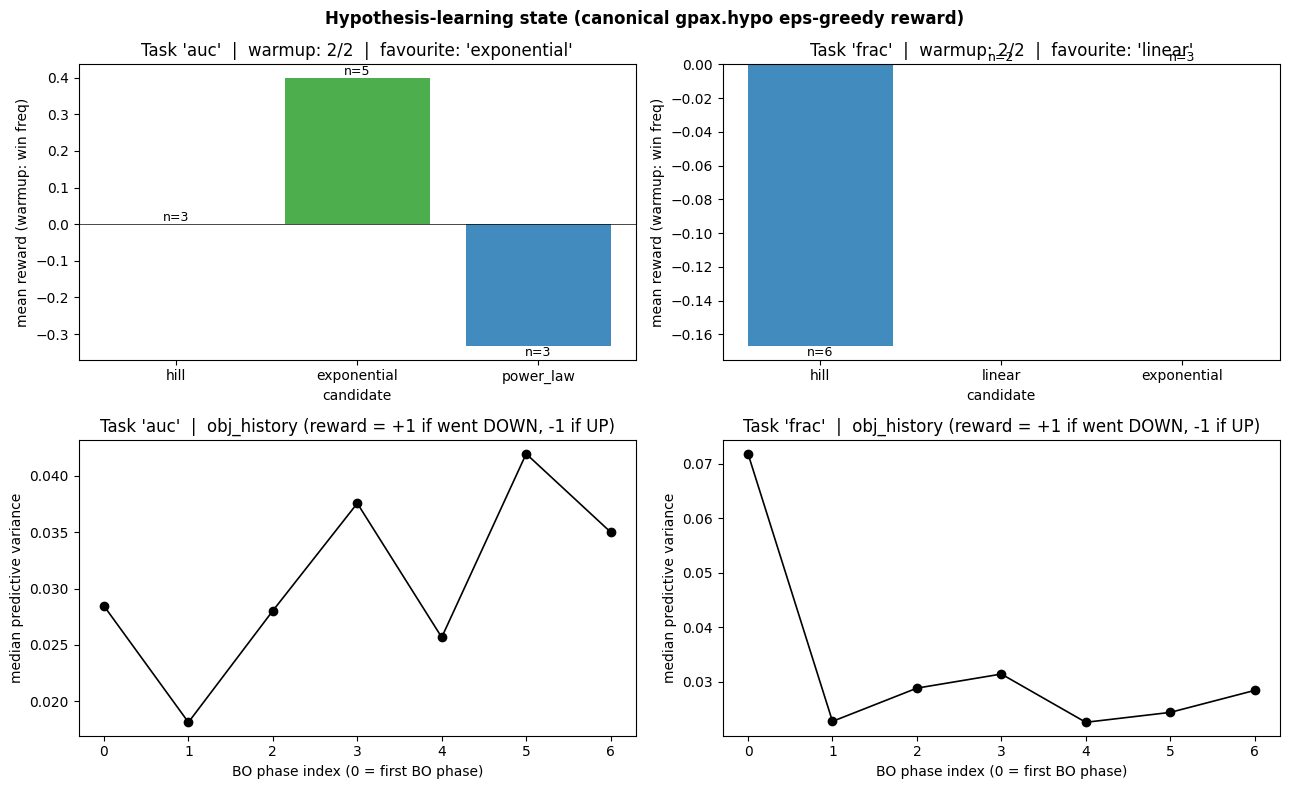

In [20]:
# Per-task hypothesis-learning diagnostics:
#   left:  mean reward per candidate (current eps-greedy favourite highlighted)
#   right: median predictive variance trajectory (the obj_history that drives reward)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for col_i, task in enumerate(agent.TASKS):
    state = agent._task_state[task]
    candidates = list(agent.candidate_hypotheses_by_task[task])
    record = state["record"]
    obj_history = state["obj_history"]
    log = state["hypothesis_log"]
    favourite = state["selected_hypothesis"]
    n_warmup_done = state.get("n_warmup_phases_done", 0)

    # --- top: mean reward per candidate ---
    ax = axes[0, col_i]
    if not log:
        ax.text(
            0.5,
            0.5,
            "No hypothesis updates yet\n(run hasn't reached BO phase)",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    else:
        colors = ["C2" if name == favourite else "C0" for name in candidates]
        bars = ax.bar(candidates, record[:, 1], color=colors, alpha=0.85)
        for bar, n in zip(bars, record[:, 0]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"n={int(n)}",
                ha="center",
                va="bottom" if bar.get_height() >= 0 else "top",
                fontsize=9,
            )
        ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("mean reward (warmup: win freq)")
    ax.set_xlabel("candidate")
    ax.set_title(
        f"Task {task!r}  |  warmup: {n_warmup_done}/{agent.n_warmup_phases}  "
        f"|  favourite: {favourite!r}"
    )

    # --- bottom: obj_history (median predictive variance per phase) ---
    ax = axes[1, col_i]
    if len(obj_history) < 2:
        ax.text(
            0.5,
            0.5,
            "Need >=2 phases for obj_history",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    else:
        # During warmup, hypothesis_log has multiple entries per phase (one per
        # candidate). Use obj_history's index as the phase index for plotting.
        phase_axis = list(range(len(obj_history)))
        ax.plot(phase_axis, obj_history, "o-", color="k", lw=1.2)
        ax.set_xlabel("BO phase index (0 = first BO phase)")
        ax.set_ylabel("median predictive variance")
        ax.set_title(
            f"Task {task!r}  |  obj_history " f"(reward = +1 if went DOWN, -1 if UP)"
        )

fig.suptitle(
    "Hypothesis-learning state (canonical gpax.hypo eps-greedy reward)",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [ ]:
# v3 K-precision-per-phase diagnostic for the AUC task.
#
# With a single Hill candidate, hypothesis-learning is degenerate. The
# meaningful convergence signal is whether the Hill K posterior is
# stabilising (its median should plateau; its width should monotonically
# tighten). We extract K (median + std) from each saved checkpoint and
# plot the trajectory. If you see K still tightening at the final phase,
# more phases would help; if it plateaued early, you could have stopped
# earlier.

import os
import joblib

TASK = "auc"
models_dir = os.path.join(path, "models")
if not os.path.isdir(models_dir):
    print(f"No models directory at {models_dir} -- run not started yet.")
else:
    # Conversion: shifted dose [0, 2] -> ms
    pulse_min_ms = bo_params[0].bounds[0]
    pulse_max_ms = bo_params[0].bounds[1]

    def shifted_to_ms(d):
        return float(d) / 2.0 * (pulse_max_ms - pulse_min_ms) + pulse_min_ms

    rows = []
    for fn in sorted(f for f in os.listdir(models_dir) if f.endswith(".joblib")):
        pid = int(fn.split("_")[-1].replace(".joblib", ""))
        try:
            payload_p = joblib.load(os.path.join(models_dir, fn))
            samples = payload_p.get("model_state", {}).get("samples", {})
            if "hill_k" not in samples:
                continue
            K_scaled = np.asarray(samples["hill_k"])
            K_ms = np.array([shifted_to_ms(v) for v in K_scaled])
            rows.append(
                {
                    "phase": pid,
                    "K_med": float(np.median(K_ms)),
                    "K_std": float(np.std(K_ms)),
                    "K_lo": float(np.quantile(K_ms, 0.025)),
                    "K_hi": float(np.quantile(K_ms, 0.975)),
                    "n_med": float(
                        np.median(samples.get("hill_n", np.array([np.nan])))
                    ),
                    "n_std": float(np.std(samples.get("hill_n", np.array([np.nan])))),
                }
            )
        except Exception as exc:
            print(f"  skipped {fn}: {exc}")

    if not rows:
        print("No usable Hill MCMC samples in saved checkpoints yet.")
    else:
        traj = pd.DataFrame(rows).sort_values("phase").reset_index(drop=True)
        print("Per-phase Hill K trajectory:")
        for _, r in traj.iterrows():
            print(
                f"  phase {int(r['phase']):2d}: K = {r['K_med']:.0f} +/- {r['K_std']:.0f} ms  "
                f"95% CI [{r['K_lo']:.0f}, {r['K_hi']:.0f}]   "
                f"n = {r['n_med']:.2f} +/- {r['n_std']:.2f}"
            )

        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
        ax = axes[0]
        ax.plot(
            traj["phase"],
            traj["K_med"],
            "o-",
            color="tab:blue",
            lw=2,
            label="K (median)",
        )
        ax.fill_between(
            traj["phase"],
            traj["K_lo"],
            traj["K_hi"],
            alpha=0.2,
            color="tab:blue",
            label="95% CI",
        )
        ax.set_xlabel("phase_id")
        ax.set_ylabel("Hill K (ms)")
        ax.set_title("Hill EC50 (K) posterior trajectory")
        ax.legend(fontsize=9)

        ax = axes[1]
        ax.plot(traj["phase"], traj["K_std"], "s-", color="tab:red", lw=2)
        ax.set_xlabel("phase_id")
        ax.set_ylabel("std(K) (ms)")
        ax.set_title("K posterior width per phase  (lower = tighter)")

        fig.suptitle("v3 Hill K convergence", fontweight="bold")
        plt.tight_layout()
        plt.show()

        # Quick verdict
        if len(traj) >= 3:
            last_std = traj["K_std"].iloc[-1]
            prev_std = traj["K_std"].iloc[-2]
            tightening = last_std < prev_std
            print()
            print(f"K width at last phase: {last_std:.0f} ms")
            print(f"K width at previous phase: {prev_std:.0f} ms")
            print(
                f"Still tightening? {tightening}  "
                f"({'continue running' if tightening else 'plateau reached -- could stop'})"
            )

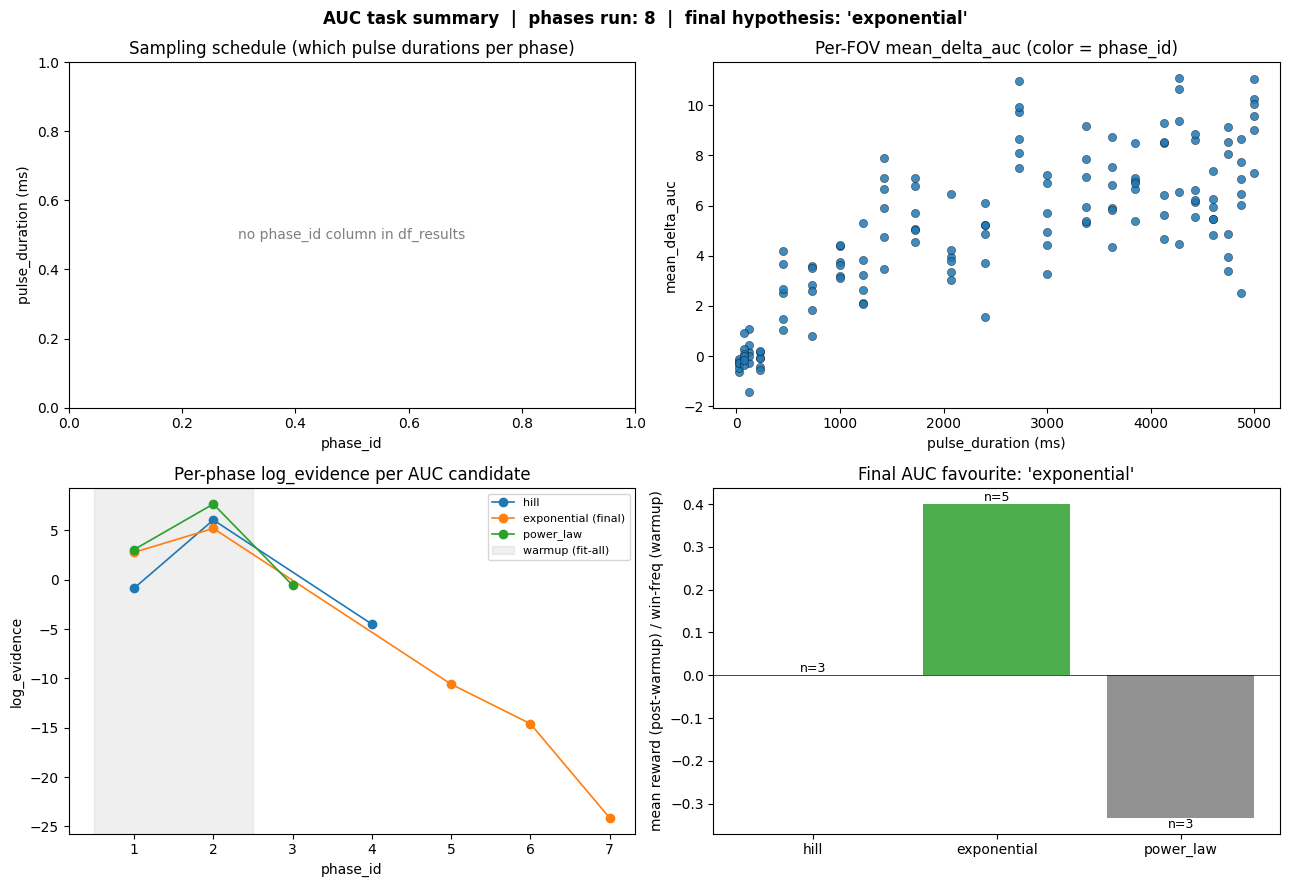


Final selected AUC hypothesis: 'exponential'
Mean reward per candidate (n = visit count):
          hill: reward=+0.000  n=3
   exponential: reward=+0.400  n=5  <-- selected
     power_law: reward=-0.333  n=3


In [22]:
# AUC-task summary: which pulse_duration was probed at which phase, and how the
# hypothesis log-evidence trajectory evolved per candidate (hill / linear / exponential).
#
# Panels:
#   (0,0) Sampling schedule    -- phase_id -> pulse_duration scatter (color = phase_id)
#   (0,1) Dose-response        -- pulse_duration -> mean_delta_auc (color = phase_id)
#   (1,0) Per-phase log_evidence for each AUC candidate (gaps = candidate not evaluated that phase)
#   (1,1) Current mean reward per candidate (final selected highlighted in green)
TASK = "auc"
task_col = agent.task_columns[TASK]

if agent.df_results is None or agent.df_results.empty:
    print("No data yet -- run the experiment first.")
else:
    df = agent.df_results.copy()
    state = agent._task_state[TASK]
    candidates = list(agent.candidate_hypotheses_by_task[TASK])
    hypo_log = state["hypothesis_log"]  # list of (phase_id, name, log_evidence)
    final = state["selected_hypothesis"]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # --- (0,0) sampling schedule: phase_id vs pulse_duration ---
    ax = axes[0, 0]
    if "phase_id" in df.columns:
        sc = ax.scatter(
            df["phase_id"],
            df["pulse_duration"],
            c=df["phase_id"],
            cmap="viridis",
            s=35,
            edgecolors="k",
            linewidths=0.3,
            alpha=0.85,
        )
        plt.colorbar(sc, ax=ax, label="phase_id")
    else:
        ax.text(
            0.5,
            0.5,
            "no phase_id column in df_results",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    ax.set_xlabel("phase_id")
    ax.set_ylabel("pulse_duration (ms)")
    ax.set_title("Sampling schedule (which pulse durations per phase)")

    # --- (0,1) dose-response, phase-colored ---
    ax = axes[0, 1]
    if "phase_id" in df.columns:
        sc = ax.scatter(
            df["pulse_duration"],
            df[task_col],
            c=df["phase_id"],
            cmap="viridis",
            s=35,
            edgecolors="k",
            linewidths=0.3,
            alpha=0.85,
        )
        plt.colorbar(sc, ax=ax, label="phase_id")
    else:
        ax.scatter(
            df["pulse_duration"],
            df[task_col],
            s=35,
            edgecolors="k",
            linewidths=0.3,
            alpha=0.85,
        )
    ax.set_xlabel("pulse_duration (ms)")
    ax.set_ylabel(task_col)
    ax.set_title(f"Per-FOV {task_col} (color = phase_id)")

    # --- (1,0) per-phase log_evidence for each candidate ---
    ax = axes[1, 0]
    if not hypo_log:
        ax.text(
            0.5,
            0.5,
            "hypothesis_log is empty\n(run did not reach BO phase)",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    else:
        log_df = pd.DataFrame(hypo_log, columns=["phase_id", "name", "log_evidence"])
        cmap = plt.get_cmap("tab10")
        for i, name in enumerate(candidates):
            sub = log_df[log_df["name"] == name].sort_values("phase_id")
            if sub.empty:
                continue
            ax.plot(
                sub["phase_id"],
                sub["log_evidence"],
                marker="o",
                lw=1.2,
                color=cmap(i),
                label=f"{name}" + (" (final)" if name == final else ""),
            )
        # Shade warmup region.
        n_warm = agent.n_warmup_phases
        if log_df["phase_id"].min() is not np.nan and n_warm > 0:
            warm_start = int(log_df["phase_id"].min())
            ax.axvspan(
                warm_start - 0.5,
                warm_start + n_warm - 0.5,
                color="gray",
                alpha=0.12,
                label="warmup (fit-all)",
            )
        ax.set_xlabel("phase_id")
        ax.set_ylabel("log_evidence")
        ax.set_title(f"Per-phase log_evidence per AUC candidate")
        ax.legend(fontsize=8, loc="best")

    # --- (1,1) final mean reward per candidate ---
    ax = axes[1, 1]
    rewards = state["record"][:, 1]
    counts = state["record"][:, 0]
    colors = ["tab:green" if name == final else "tab:gray" for name in candidates]
    bars = ax.bar(candidates, rewards, color=colors, alpha=0.85)
    for bar, n in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"n={int(n)}",
            ha="center",
            va="bottom" if bar.get_height() >= 0 else "top",
            fontsize=9,
        )
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel("mean reward (post-warmup) / win-freq (warmup)")
    ax.set_title(f"Final AUC favourite: {final!r}")

    fig.suptitle(
        f"AUC task summary  |  phases run: {len(agent._iteration_means)}  |  "
        f"final hypothesis: {final!r}",
        fontsize=12,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # Compact text summary
    print(f"\nFinal selected AUC hypothesis: {final!r}")
    print("Mean reward per candidate (n = visit count):")
    for name, r, n in zip(candidates, rewards, counts):
        flag = "  <-- selected" if name == final else ""
        print(f"  {name:>12s}: reward={r:+.3f}  n={int(n)}{flag}")

UnboundLocalError: cannot access local variable 'i' where it is not associated with a value

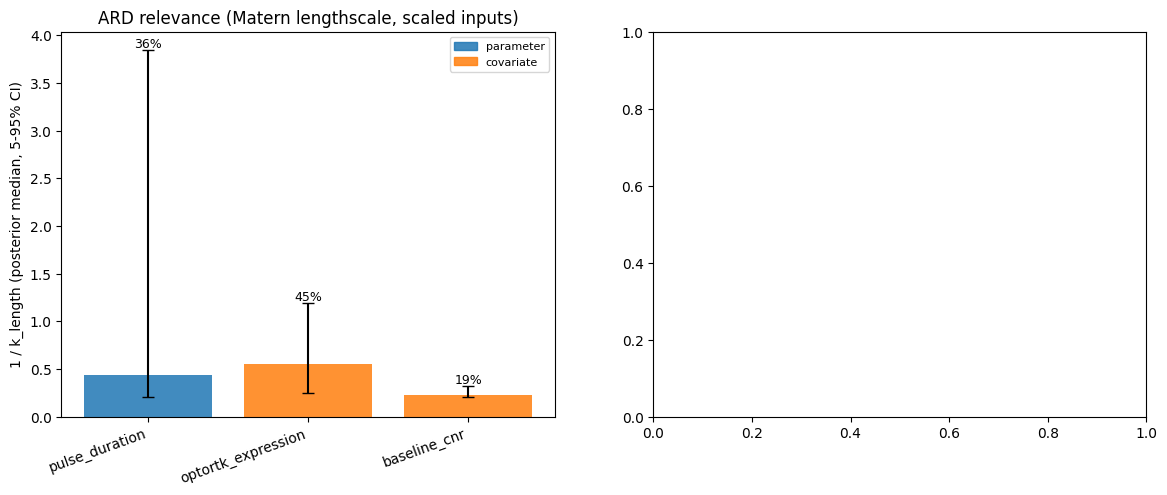

In [23]:
# Covariate-contribution diagnostics for the AUC task.
#
# Two complementary views:
#
#   LEFT  -- ARD relevance: posterior of 1 / k_length per input dim.
#            Matern + ARD learns a separate lengthscale for each input;
#            short lengthscale = GP varies quickly along that dim to explain
#            the data = informative. Bars are posterior median, error bars
#            are the 5-95% credible interval (over MCMC samples).
#            *Caveat*: lengthscale_prior_dist = Uniform(0.1, 1.0) so 1/k_length
#            is bounded in [1, 10] -- ratios across dims, not absolute values,
#            are the meaningful quantity.
#
#   RIGHT -- Decision sensitivity: hold pulse_duration at a low / mid / high
#            representative value and the other covariates at their median;
#            sweep one covariate across its 5-95% observed range; record
#            the predicted mean_delta_auc swing (max - min). Bigger swing
#            = ignoring that covariate would distort predictions more.
#            *Caveat*: one-at-a-time, ignores interactions.

import gpax
import gpax.utils

TASK = "auc"

if (
    TASK not in agent._gp_models_by_task
    or agent.df_results is None
    or agent.df_results.empty
):
    print("AUC GP not fit yet -- run the experiment first.")
else:
    gp = agent._gp_models_by_task[TASK]
    y_scaler = agent._y_scalers_by_task[TASK]
    x_scaler = agent._x_scaler

    param_names = [p.name for p in agent.parameters_to_optimize]
    cov_names = [c.name for c in agent.bo_covariates]
    dim_names = param_names + cov_names  # GP input order: params first, then covariates
    n_params = len(param_names)

    samples = gp.get_samples(chain_dim=False)
    if "k_length" not in samples:
        print("k_length not in MCMC samples -- non-ARD kernel? skipping ARD panel.")
        k_length = None
    else:
        k_length = np.asarray(samples["k_length"])  # (S, D) in scaled-input space

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---------- LEFT: ARD relevance per input dim ----------
    ax = axes[0]
    if k_length is None or k_length.ndim != 2 or k_length.shape[1] != len(dim_names):
        ax.text(
            0.5,
            0.5,
            "k_length not available or shape mismatch",
            ha="center",
            va="center",
            transform=ax.transAxes,
            color="gray",
        )
    else:
        relevance = 1.0 / k_length
        rel_med = np.median(relevance, axis=0)
        rel_lo = np.quantile(relevance, 0.05, axis=0)
        rel_hi = np.quantile(relevance, 0.95, axis=0)
        rel_pct = 100.0 * rel_med / rel_med.sum()
        colors = [
            "tab:blue" if i < n_params else "tab:orange" for i in range(len(dim_names))
        ]
        ax.bar(
            dim_names,
            rel_med,
            yerr=[rel_med - rel_lo, rel_hi - rel_med],
            color=colors,
            alpha=0.85,
            capsize=4,
        )
        for i, pct in enumerate(rel_pct):
            ax.text(i, rel_hi[i], f"{pct:.0f}%", ha="center", va="bottom", fontsize=9)
        ax.set_ylabel("1 / k_length (posterior median, 5-95% CI)")
        ax.set_title("ARD relevance (Matern lengthscale, scaled inputs)")
        plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
        legend_handles = [
            plt.Rectangle(
                (0, 0), 1, 1, color="tab:blue", alpha=0.85, label="parameter"
            ),
            plt.Rectangle(
                (0, 0), 1, 1, color="tab:orange", alpha=0.85, label="covariate"
            ),
        ]
        ax.legend(handles=legend_handles, fontsize=8, loc="upper right")

    # ---------- RIGHT: predictive sensitivity sweep ----------
    ax = axes[1]
    df = agent.df_results
    cov_vals = df[cov_names].to_numpy(dtype=float)
    cov_med = np.median(cov_vals, axis=0)
    pulse_obs = df[param_names[0]].to_numpy()
    pulse_repr = np.quantile(pulse_obs, [0.1, 0.5, 0.9])
    n_sweep = 25

    rng_key, rng_key_pred = gpax.utils.get_keys()
    sensitivities = np.zeros((len(pulse_repr), len(cov_names)))

    for j, pulse_fixed in enumerate(pulse_repr):
        for i, _cov_name in enumerate(cov_names):
            cov_range = np.linspace(
                np.quantile(cov_vals[:, i], 0.05),
                np.quantile(cov_vals[:, i], 0.95),
                n_sweep,
            )
            cov_sweep = np.tile(cov_med, (n_sweep, 1))
            cov_sweep[:, i] = cov_range
            x_full = np.column_stack([np.full(n_sweep, pulse_fixed), cov_sweep])
            x_scaled = x_scaler.transform(x_full)
            y_pred_scaled, _ = gp.predict_in_batches(
                rng_key_pred,
                x_scaled,
                batch_size=1000,
                n=4,
                noiseless=True,
            )
            y_pred = y_scaler.inverse_transform(
                np.asarray(y_pred_scaled).reshape(-1, 1)
            ).flatten()
            sensitivities[j, i] = y_pred.max() - y_pred.min()

    bar_width = 0.25
    x = np.arange(len(cov_names))
    for j, pulse_fixed in enumerate(pulse_repr):
        ax.bar(
            x + (j - 1) * bar_width,
            sensitivities[j],
            width=bar_width,
            label=f"pulse={pulse_fixed:.0f} ms",
            alpha=0.85,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(cov_names, rotation=20, ha="right")
    ax.set_ylabel(
        "predicted mean_delta_auc swing\n(max - min over 5-95% covariate range)"
    )
    ax.set_title("Decision sensitivity (one-at-a-time, others fixed at median)")
    ax.legend(fontsize=8)

    fig.suptitle(
        "AUC task -- how much do covariates contribute?", fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

    # ----- Text summary -----
    if k_length is not None and k_length.shape[1] == len(dim_names):
        print("ARD relevance ranking (higher = more informative input):")
        order = np.argsort(rel_med)[::-1]
        for idx in order:
            kind = "param" if idx < n_params else "covariate"
            print(
                f"  {dim_names[idx]:>22s} ({kind:>9s}): "
                f"1/l = {rel_med[idx]:.3f}  ({rel_pct[idx]:.1f}% of total)"
            )

    print(
        "\nDecision sensitivity (predicted AUC swing per covariate, averaged over pulse levels):"
    )
    sens_mean = sensitivities.mean(axis=0)
    for i, name in enumerate(cov_names):
        print(
            f"  {name:>22s}: avg swing = {sens_mean[i]:.4f}  "
            f"(low={sensitivities[0, i]:.4f}, mid={sensitivities[1, i]:.4f}, "
            f"high={sensitivities[2, i]:.4f})"
        )

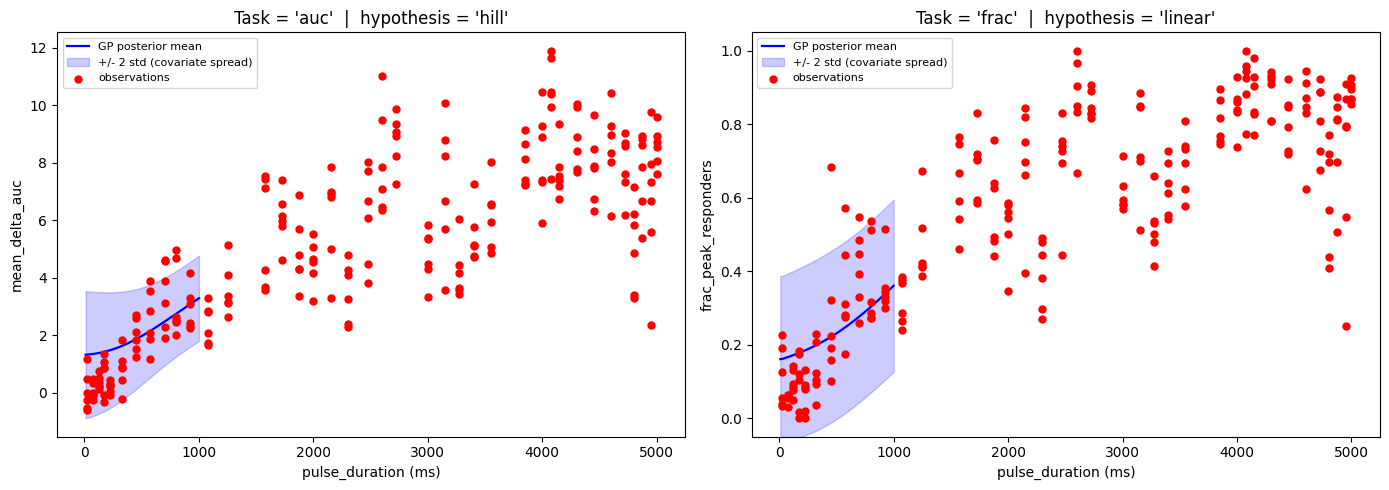

In [ ]:
# GP-predicted dose-response curves per task (marginalised over covariates).
import gpax
import gpax.utils

if (
    agent._gp_models_by_task
    and agent.df_results is not None
    and not agent.df_results.empty
):
    df = agent.df_results

    rng_key, rng_key_pred = gpax.utils.get_keys()
    pulse_grid = np.arange(10.0, 1000.0 + 10.0, 10.0)

    n_cov_samples = 50
    cov_vals = df[[c.name for c in agent.bo_covariates]].to_numpy(dtype=float)
    rng = np.random.default_rng(0)
    cov_idx = rng.integers(0, cov_vals.shape[0], size=n_cov_samples)
    cov_samples = cov_vals[cov_idx]

    x_full = np.hstack(
        [
            np.repeat(pulse_grid[:, None], n_cov_samples, axis=0),
            np.tile(cov_samples, (len(pulse_grid), 1)),
        ]
    )
    x_full_scaled = agent._x_scaler.transform(x_full)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax_idx, task in enumerate(agent.TASKS):
        ax = axes[ax_idx]
        gp_model = agent._gp_models_by_task[task]
        y_scaler = agent._y_scalers_by_task[task]
        col = agent.task_columns[task]

        y_pred_scaled, _ = gp_model.predict_in_batches(
            rng_key_pred,
            x_full_scaled,
            batch_size=1000,
            n=8,
            noiseless=True,
        )
        y_pred_logit_or_lin = y_scaler.inverse_transform(
            np.asarray(y_pred_scaled).reshape(-1, 1)
        ).flatten()
        # If task is logit-scaled, invert back to probability space.
        if agent.task_logit[task]:
            y_pred = _inv_logit(y_pred_logit_or_lin)
        else:
            y_pred = y_pred_logit_or_lin

        y_pred_2d = y_pred.reshape(len(pulse_grid), n_cov_samples)
        y_pred_mean = y_pred_2d.mean(axis=1)
        y_pred_std = y_pred_2d.std(axis=1)

        ax.plot(pulse_grid, y_pred_mean, "b-", lw=1.6, label="GP posterior mean")
        ax.fill_between(
            pulse_grid,
            y_pred_mean - 2 * y_pred_std,
            y_pred_mean + 2 * y_pred_std,
            alpha=0.2,
            color="blue",
            label="+/- 2 std (covariate spread)",
        )
        ax.scatter(
            df["pulse_duration"],
            df[col],
            c="red",
            s=25,
            zorder=5,
            label="observations",
        )
        ax.set_xlabel("pulse_duration (ms)")
        ax.set_ylabel(col)
        locked = agent._task_state[task]["selected_hypothesis"]
        ax.set_title(
            f"Task = {task!r}  |  hypothesis = {locked!r}"
            if locked
            else f"Task = {task!r}  (current best, not yet locked)"
        )
        ax.legend(fontsize=8)
        if agent.task_logit[task]:
            ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()
else:
    print("GPs not fit yet (run hasn't reached BO phase).")

=== Winning model: 'exponential'  (task = 'auc') ===
Parameter posteriors (median, 95% CI):

               A (asymptote) (     exp_amp): median =     9.31      AUC   std =    2.19   95% CI: [5.45, 13.3]
         tau (time constant) (     exp_tau): median = 1.74e+03       ms   std = 2.07e+03   95% CI: [644, 7.07e+03]


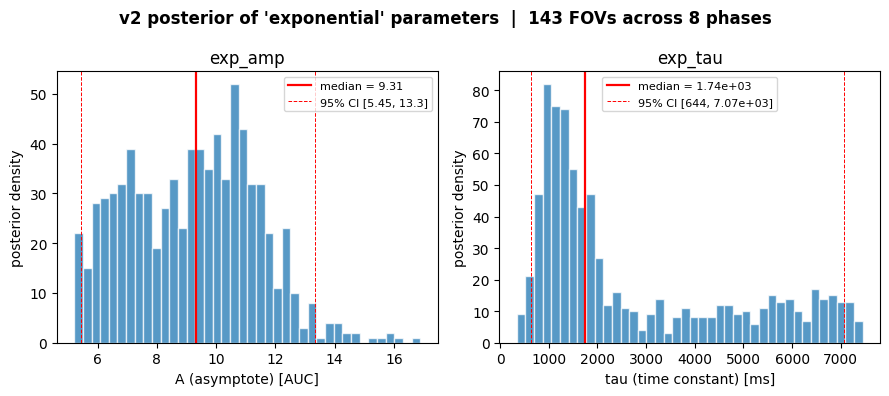

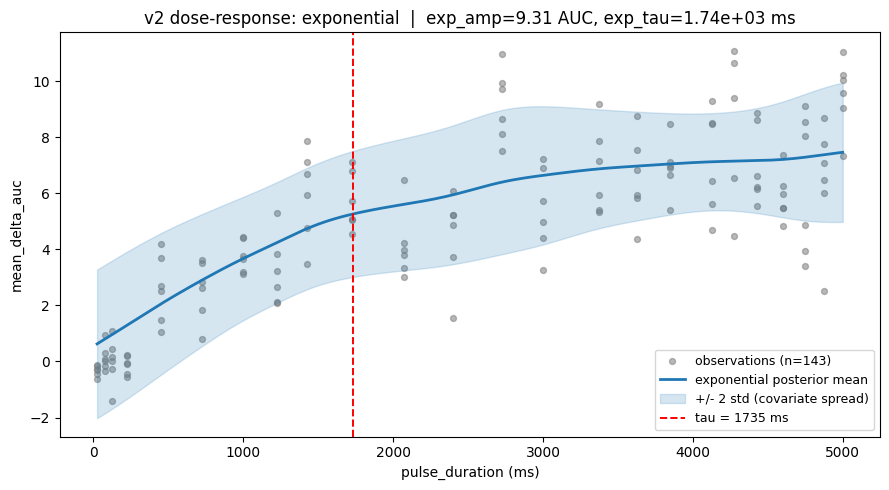


Slide-ready summary:
  "v2 fit: exponential-saturation dose-response with tau = 1735 +/- 2066 ms, asymptote A = 9.31 +/- 2.19 AUC, at 8 phases (~4.1 h microscope time)."


In [24]:
# Winning-model parameter posteriors (the actual scientific output of v2).
#
# Hypothesis-learning picks the *family* (hill / exp / power_law); the
# parameter posteriors below pin down WHERE on that family the data lies.
# Together they are the dose-response result. For Hill these are:
#   - V_max: response asymptote (AUC units)
#   - K     : EC50 dose (ms)  <-- the headline biological number
#   - n     : Hill coefficient (unitless; n > 1 = cooperative / sigmoidal)
# For exp:    A (asymptote), tau (time constant, ms)
# For power_law: a (prefactor at midpoint dose), b (exponent, unitless)
#
# Dose-space parameters are converted from the GP's standardised input space
# back to milliseconds; y-space parameters (asymptotes, prefactors) are
# converted from standardised AUC back to raw AUC via the y_scaler.

import numpy as np

TASK = "auc"

if (
    TASK not in agent._gp_models_by_task
    or agent.df_results is None
    or agent.df_results.empty
):
    print("Run hasn't reached BO phase yet -- no winning model.")
else:
    state = agent._task_state[TASK]
    final = state.get("selected_hypothesis")
    gp = agent._gp_models_by_task[TASK]
    y_scaler = agent._y_scalers_by_task[TASK]
    samples = gp.get_samples(chain_dim=False)

    # --- Dose-space <-> ms conversion (matches StandardScalerBounds + _shifted_dose) ---
    pulse_min_ms = bo_params[0].bounds[0]
    pulse_max_ms = bo_params[0].bounds[1]

    def shifted_to_ms(d_shifted_arr):
        # _shifted_dose maps scaled_dose [-1, 1] -> shifted [0, 2]
        # StandardScalerBounds maps original [min, max] -> scaled [-1, 1]
        # So: ms = shifted/2 * (max - min) + min
        d_shifted_arr = np.asarray(d_shifted_arr, dtype=float)
        return d_shifted_arr / 2.0 * (pulse_max_ms - pulse_min_ms) + pulse_min_ms

    def yscaled_to_raw(arr):
        arr = np.asarray(arr, dtype=float).reshape(-1, 1)
        return y_scaler.inverse_transform(arr).flatten()

    # --- Parameter specs per candidate ---
    # Each tuple: (sample_key, display_label, conversion, unit)
    # conversions: "dose_to_ms" | "yscaled_to_raw" | "raw"
    PARAM_SPECS = {
        "hill": [
            ("hill_vmax", "V_max (asymptote)", "yscaled_to_raw", "AUC"),
            ("hill_k", "K (EC50)", "dose_to_ms", "ms"),
            ("hill_n", "n (Hill coefficient)", "raw", "unitless"),
        ],
        "exponential": [
            ("exp_amp", "A (asymptote)", "yscaled_to_raw", "AUC"),
            ("exp_tau", "tau (time constant)", "dose_to_ms", "ms"),
        ],
        "power_law": [
            ("pow_a", "a (AUC at midpoint dose)", "yscaled_to_raw", "AUC"),
            ("pow_b", "b (exponent)", "raw", "unitless"),
        ],
    }

    if final not in PARAM_SPECS:
        print(f"No parameter spec defined for {final!r}.")
    else:
        specs = PARAM_SPECS[final]
        present = [(k, lbl, conv, unit) for k, lbl, conv, unit in specs if k in samples]
        missing = [k for k, *_ in specs if k not in samples]
        if missing:
            print(f"WARN: missing sample keys: {missing}")

        # --- Parameter posterior histograms ---
        fig, axes = plt.subplots(1, len(present), figsize=(4.5 * len(present), 4))
        if len(present) == 1:
            axes = [axes]

        print(f"=== Winning model: {final!r}  (task = {TASK!r}) ===")
        print(f"Parameter posteriors (median, 95% CI):\n")
        param_rows = []  # for the summary table
        for ax, (key, label, conv, unit) in zip(axes, present):
            s_scaled = np.asarray(samples[key])
            if conv == "dose_to_ms":
                s = shifted_to_ms(s_scaled)
            elif conv == "yscaled_to_raw":
                s = yscaled_to_raw(s_scaled)
            else:
                s = s_scaled
            med = float(np.median(s))
            lo = float(np.quantile(s, 0.025))
            hi = float(np.quantile(s, 0.975))
            std = float(np.std(s))
            param_rows.append((label, key, med, std, lo, hi, unit))

            ax.hist(s, bins=40, color="tab:blue", alpha=0.75, edgecolor="white")
            ax.axvline(med, color="red", lw=1.6, label=f"median = {med:.3g}")
            ax.axvline(lo, color="red", lw=0.7, ls="--")
            ax.axvline(
                hi, color="red", lw=0.7, ls="--", label=f"95% CI [{lo:.3g}, {hi:.3g}]"
            )
            ax.set_xlabel(f"{label} [{unit}]")
            ax.set_ylabel("posterior density")
            ax.set_title(f"{key}")
            ax.legend(fontsize=8, loc="best")

            print(
                f"  {label:>26s} ({key:>12s}): "
                f"median = {med:>8.3g} {unit:>8s}   "
                f"std = {std:>7.3g}   "
                f"95% CI: [{lo:.3g}, {hi:.3g}]"
            )

        fig.suptitle(
            f"v2 posterior of {final!r} parameters  |  "
            f"{len(agent.df_results)} FOVs across {agent.iteration} phases",
            fontsize=12,
            fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

        # --- Bonus: overlay the fitted curve on data with parameter labels ---
        import gpax.utils

        rng_key, rng_key_pred = gpax.utils.get_keys()
        pulse_grid = np.linspace(pulse_min_ms, pulse_max_ms, 200)

        df_res = agent.df_results
        cov_vals = df_res[[c.name for c in agent.bo_covariates]].to_numpy(dtype=float)
        n_cov_samples = 50
        rng = np.random.default_rng(0)
        cov_samples = cov_vals[rng.integers(0, cov_vals.shape[0], size=n_cov_samples)]

        x_full = np.hstack(
            [
                np.repeat(pulse_grid[:, None], n_cov_samples, axis=0),
                np.tile(cov_samples, (len(pulse_grid), 1)),
            ]
        )
        x_full_scaled = agent._x_scaler.transform(x_full)

        y_pred_scaled, _ = gp.predict_in_batches(
            rng_key_pred,
            x_full_scaled,
            batch_size=1000,
            n=8,
            noiseless=True,
        )
        y_pred = yscaled_to_raw(np.asarray(y_pred_scaled))
        y_pred_2d = y_pred.reshape(len(pulse_grid), n_cov_samples)
        y_mean = y_pred_2d.mean(axis=1)
        y_std = y_pred_2d.std(axis=1)

        fig2, ax2 = plt.subplots(figsize=(9, 5))
        ax2.scatter(
            df_res["pulse_duration"],
            df_res["mean_delta_auc"],
            c="tab:gray",
            s=18,
            alpha=0.55,
            label=f"observations (n={len(df_res)})",
        )
        ax2.plot(
            pulse_grid, y_mean, color="tab:blue", lw=2, label=f"{final} posterior mean"
        )
        ax2.fill_between(
            pulse_grid,
            y_mean - 2 * y_std,
            y_mean + 2 * y_std,
            alpha=0.18,
            color="tab:blue",
            label="+/- 2 std (covariate spread)",
        )

        # Annotate EC50 / tau on the plot if applicable
        if final == "hill":
            K_med = next((r[2] for r in param_rows if r[1] == "hill_k"), None)
            if K_med is not None:
                ax2.axvline(
                    K_med, color="red", ls="--", lw=1.4, label=f"K = {K_med:.0f} ms"
                )
        elif final == "exponential":
            tau_med = next((r[2] for r in param_rows if r[1] == "exp_tau"), None)
            if tau_med is not None:
                ax2.axvline(
                    tau_med,
                    color="red",
                    ls="--",
                    lw=1.4,
                    label=f"tau = {tau_med:.0f} ms",
                )

        ax2.set_xlabel("pulse_duration (ms)")
        ax2.set_ylabel("mean_delta_auc")
        param_pretty = ", ".join(f"{r[1]}={r[2]:.3g} {r[6]}" for r in param_rows)
        ax2.set_title(f"v2 dose-response: {final}  |  {param_pretty}")
        ax2.legend(fontsize=9, loc="lower right")
        plt.tight_layout()
        plt.show()

        # --- Slide-ready summary line ---
        print()
        print("Slide-ready summary:")
        if final == "hill":
            K = next(r[2] for r in param_rows if r[1] == "hill_k")
            K_std = next(r[3] for r in param_rows if r[1] == "hill_k")
            n_med = next(r[2] for r in param_rows if r[1] == "hill_n")
            n_std = next(r[3] for r in param_rows if r[1] == "hill_n")
            V = next(r[2] for r in param_rows if r[1] == "hill_vmax")
            V_std = next(r[3] for r in param_rows if r[1] == "hill_vmax")
            print(
                f'  "v2 fit: Hill dose-response with EC50 K = {K:.0f} +/- {K_std:.0f} ms, '
                f"Hill coefficient n = {n_med:.2f} +/- {n_std:.2f}, asymptote V_max = {V:.2f} +/- {V_std:.2f} AUC, "
                f'at {agent.iteration} phases (~{agent.iteration * N_FRAMES / 60:.1f} h microscope time)."'
            )
        elif final == "exponential":
            tau = next(r[2] for r in param_rows if r[1] == "exp_tau")
            tau_std = next(r[3] for r in param_rows if r[1] == "exp_tau")
            A = next(r[2] for r in param_rows if r[1] == "exp_amp")
            A_std = next(r[3] for r in param_rows if r[1] == "exp_amp")
            print(
                f'  "v2 fit: exponential-saturation dose-response with tau = {tau:.0f} +/- {tau_std:.0f} ms, '
                f"asymptote A = {A:.2f} +/- {A_std:.2f} AUC, "
                f'at {agent.iteration} phases (~{agent.iteration * N_FRAMES / 60:.1f} h microscope time)."'
            )
        elif final == "power_law":
            b = next(r[2] for r in param_rows if r[1] == "pow_b")
            b_std = next(r[3] for r in param_rows if r[1] == "pow_b")
            print(
                f'  "v2 fit: power-law dose-response with exponent b = {b:.2f} +/- {b_std:.2f}, '
                f"no saturation within 25-5000 ms, "
                f'at {agent.iteration} phases (~{agent.iteration * N_FRAMES / 60:.1f} h microscope time)."'
            )